Purpose: Make various plots of CAM gene expression (both in terms of maSigPro results and not).<br>
Author: Anna Pardo<br>
Date initiated: Dec. 9, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# load time-structured gene information
cinfo = pd.read_csv("./clusters_ngenes_gt_ztgroup_with36-61-43.txt",sep="\t",header="infer")
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [3]:
# load CAM gene annotation
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [4]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [5]:
# add subgenome column
sg = []
for i in list(cam["GeneID"]):
    if i.startswith("Yucal"):
        sg.append("Ya")
    else:
        sg.append("Yf")
cam["subgenome"] = sg

In [6]:
# overwrite cam with the new subgenome col
cam.to_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header=True,index=False)

In [4]:
# load TPM data
mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_6046/3237519056.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [5]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [6]:
# subset by genotype (actually used in maSigPro) and ZT (every 4 hours)
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]
zttpm = zttpm[~zttpm["genotype"].isin(["15","6","16","20","12","50"])]

In [10]:
zttpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.0,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.0,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.0,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418
5,Y104,1AB,6.0,W,21.0,gloriosa,54.385723,5.745473,0.0,17.707487,...,0.0,1.325587,20.929404,2.159383,7.363694,0.000000,2.504658,15.673893,0.0,0.000000
6,Y105,18,6.0,W,21.0,gloriosa,47.391406,8.458668,0.0,15.536940,...,0.0,7.491513,2.153592,6.520598,14.513037,2.782378,2.331412,20.726688,0.0,0.000000


In [11]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [12]:
# test section: plot the profile of Ya_BPPC_1
## subset the TPM data
gid = cam.loc[cam['gene_abbr_unique'] == "Ya_BPPC_1", 'GeneID'].iloc[0]
gid

'Yucal.07G108300.v2.1'

In [13]:
subtpm = zttpm[["sample_name","genotype","treat","ZT",gid]]
subtpm.head()

,sample_name,genotype,treat,ZT,Yucal.07G108300.v2.1
0,Y1,18,W,1.0,47.645585
3,Y101,2AB,D,1.0,32.852926
4,Y103,2AB,D,1.0,53.977262
5,Y104,1AB,W,21.0,31.578968
6,Y105,18,W,21.0,124.717355


In [15]:
len(zttpm["genotype"].unique())

20

<AxesSubplot: xlabel='ZT', ylabel='Yucal.07G108300.v2.1'>

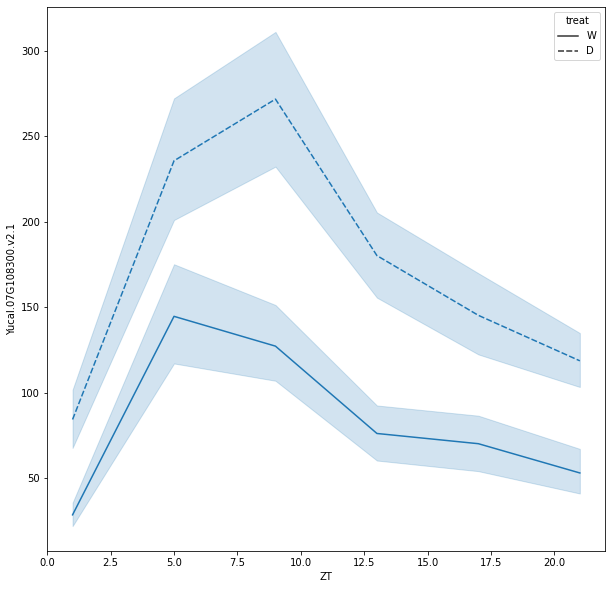

In [17]:
fig,ax = plt.subplots(figsize=(10,10))
sns.lineplot(data=subtpm,x="ZT",y=gid,style="treat")

<AxesSubplot: xlabel='ZT', ylabel='Yucal.07G108300.v2.1'>

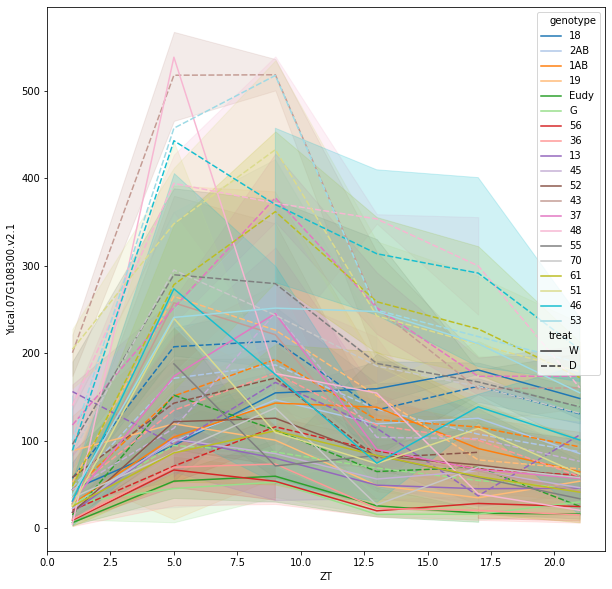

In [16]:
# try plotting all genotypes on one line graph...see how it goes!
fig,ax = plt.subplots(figsize=(10,10))
sns.lineplot(data=subtpm,x="ZT",y=gid,hue="genotype",style="treat",palette="tab20")

Some plots to make:<br>
- Each CAM gene family's profile (by subgenome & treatment)
    - also: look at those found in the time-structured genes as well as all of them together and those not found in the time-structured genes
- Each CAM gene family (by subgenome, treatment, & gene ID)
- Also by genotype (each family and I think each gene)...although with 20 genotypes this could become unwieldy
- In maSigPro clusters: plot CAM genes (all, light, & dark, or by family) over cluster profiles
- not specific to CAM but: probably, make overall plots for each ZT-peak cluster group

In [19]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [7]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # pull max TPM (out of curiosity)
    maxtpm = int(round(max(cpdf["TPM"]),0))
    
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext+fam+" (max TPM: "+str(maxtpm)+")",fontsize=tf)

In [8]:
# rework plottpm similarly
def plottpm_genefamily(tpm,genefam,camdf=cam):
    camfam = camdf[camdf["gene_abbr"]==genefam]
    csgd = {}
    for i in range(len(camfam.index)):
        csgd[camfam.iloc[i,0]] = camfam.iloc[i,6]
    cgenes = [i for i in list(camfam["GeneID"].unique()) if i in tpm.columns]
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    plong["subgenome"] = plong["GeneID"].map(csgd)
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [9]:
# set up a column in the 'cam' object stating whether a gene is time-structured or not, 
# and if so, what cluster & ZTpeak is it in? (separate columns)

# to do this: load cluster membership data
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
            gt = "37"
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
        
    gtc["genotype"] = gt
    # set up a CAM column
    camornot = []
    for i in gtc["GeneID"]:
        if i in camids:
            camornot.append("Y")
        else:
            camornot.append("N")
    gtc["CAM_notCAM"] = camornot
    
    # set up a subgenome column
    sg = []
    for i in gtc["GeneID"]:
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    gtc["subgenome"] = sg
    
    # set up a genotype_cluster column
    gtc["gtc"] = gtc["genotype"]+"_"+gtc["cluster"].astype(str)
    
    return gtc

In [10]:
camids = list(cam["GeneID"].unique())

In [3]:
dflist = []
for f in os.listdir("./"):
    if(f.endswith("clusters.txt") and f.startswith("Yg")):
        print(f)
        gt = f.split("_")[0].lstrip("Yg")
        print(gt)
        dflist.append(load_sum_gt(gt))
dflist.append(load_sum_gt("gt37"))

YgG_hclust_k6_clusters.txt
G


NameError: name 'load_sum_gt' is not defined

In [12]:
allclusters = pd.concat(dflist)
allclusters.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc
0,1,Yucal.01G003400.v2.1,G,N,Ya,G_1
1,1,Yucal.01G004800.v2.1,G,N,Ya,G_1
2,2,Yucal.01G004900.v2.1,G,N,Ya,G_2
3,3,Yucal.01G005300.v2.1,G,N,Ya,G_3
4,4,Yucal.01G012100.v2.1,G,N,Ya,G_4


In [39]:
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [40]:
len(allclusters.index)

395434

In [13]:
allclusters = allclusters.merge(cinfo[["gtc","ZTpeak"]],on="gtc",how="left")
allclusters.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc,ZTpeak
0,1,Yucal.01G003400.v2.1,G,N,Ya,G_1,1.0
1,1,Yucal.01G004800.v2.1,G,N,Ya,G_1,1.0
2,2,Yucal.01G004900.v2.1,G,N,Ya,G_2,9.0
3,3,Yucal.01G005300.v2.1,G,N,Ya,G_3,5.0
4,4,Yucal.01G012100.v2.1,G,N,Ya,G_4,21.0


In [14]:
# now, merge with the CAM data
camclust = allclusters[allclusters["CAM_notCAM"]=="Y"]
camclust.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc,ZTpeak
229,6,Yucal.02G112700.v2.1,G,Y,Ya,G_6,9.0
338,2,Yucal.03G005000.v2.1,G,Y,Ya,G_2,9.0
527,1,Yucal.04G178900.v2.1,G,Y,Ya,G_1,1.0
854,2,Yucal.07G108400.v2.1,G,Y,Ya,G_2,9.0
855,2,Yucal.07G108500.v2.1,G,Y,Ya,G_2,9.0


In [43]:
len(camclust.index)

490

In [48]:
len(camclust["GeneID"].unique())

67

In [49]:
len(cam["GeneID"].unique())

79

In [44]:
len(cam.index)

79

In [15]:
camts = cam.merge(camclust[["GeneID","subgenome","gtc","ZTpeak"]],on=["GeneID","subgenome"],how="left")
len(camts.index)

502

In [53]:
camts.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,gtc,ZTpeak,isTS
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,36_6,9.0,time-structured
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,13_2,5.0,time-structured
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,45_5,5.0,time-structured
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,19_4,1.0,time-structured
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,51_6,1.0,time-structured


In [16]:
ists = []
for i in range(len(camts.index)):
    if type(camts.iloc[i,7])!=str:
        ists.append("not time-structured")
    else:
        ists.append("time-structured")
camts["isTS"] = ists

In [19]:
camts[camts["isTS"]=="not time-structured"]

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,gtc,ZTpeak,isTS
316,YufilH1003886m.g,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Yf_bCA1234_1,Yf,NaN,NaN,not time-structured
352,YufilH1023221m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Yf_bCA5_2,Yf,NaN,NaN,not time-structured
353,YufilH1042054m.g,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Yf_bCA5_3,Yf,NaN,NaN,not time-structured
368,YufilH1024704m.g,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Yf_NAD-MDH-cp_2,Yf,NaN,NaN,not time-structured
376,YufilH1021234m.g,OG0002435,CAM-dark,NAD-dependent malate dehydrogenase (cytosolic),NAD-MDH-ct,Yf_NAD-MDH-ct_1,Yf,NaN,NaN,not time-structured
393,YufilH1068648m.g,OG0007558,CAM-dark,NADP-dependent malate dehydrogenase,NADP-MDH,Yf_NADP-MDH_2,Yf,NaN,NaN,not time-structured
439,YufilH1069012m.g,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,Yf_PPCK_4,Yf,NaN,NaN,not time-structured
440,YufilH1072272m.g,OG0001083,CAM-dark,phosphoenolpyruvate carboxylase kinase,PPCK,Yf_PPCK_5,Yf,NaN,NaN,not time-structured
450,YufilH1003177m.g,OG0000793,CAM-light,NADP-dependent malic enzyme,NADP-ME,Yf_NADP-ME_1,Yf,NaN,NaN,not time-structured
470,YufilH1082500m.g,OG0000793,CAM-light,NADP-dependent malic enzyme,NADP-ME,Yf_NADP-ME_5,Yf,NaN,NaN,not time-structured


In [17]:
len(camts[camts["gene_abbr"]=="BPPC"]["isTS"].unique())

1

In [89]:
for i in camts2["gene_abbr"].unique():
    df = camts2[camts2["gene_abbr"]==i]
    print(i)
    print(len(df["GeneID"].unique()))

bCA1234
4
bCA5
4
NAD-MDH-cp
7
NAD-MDH-ct
6
NADP-MDH
2
BPPC
4
PPPC
8
PPCK
12
NAD-ME
5
NADP-ME
11
PEPCK
3
PPDK
4


In [18]:
keepgenes = []
for i in camts["GeneID"].unique():
    if i in zttpm.columns:
        keepgenes.append(i)

In [19]:
camts2 = camts[camts["GeneID"].isin(keepgenes)]

In [90]:
len(camts2["gene_abbr"].unique())

12

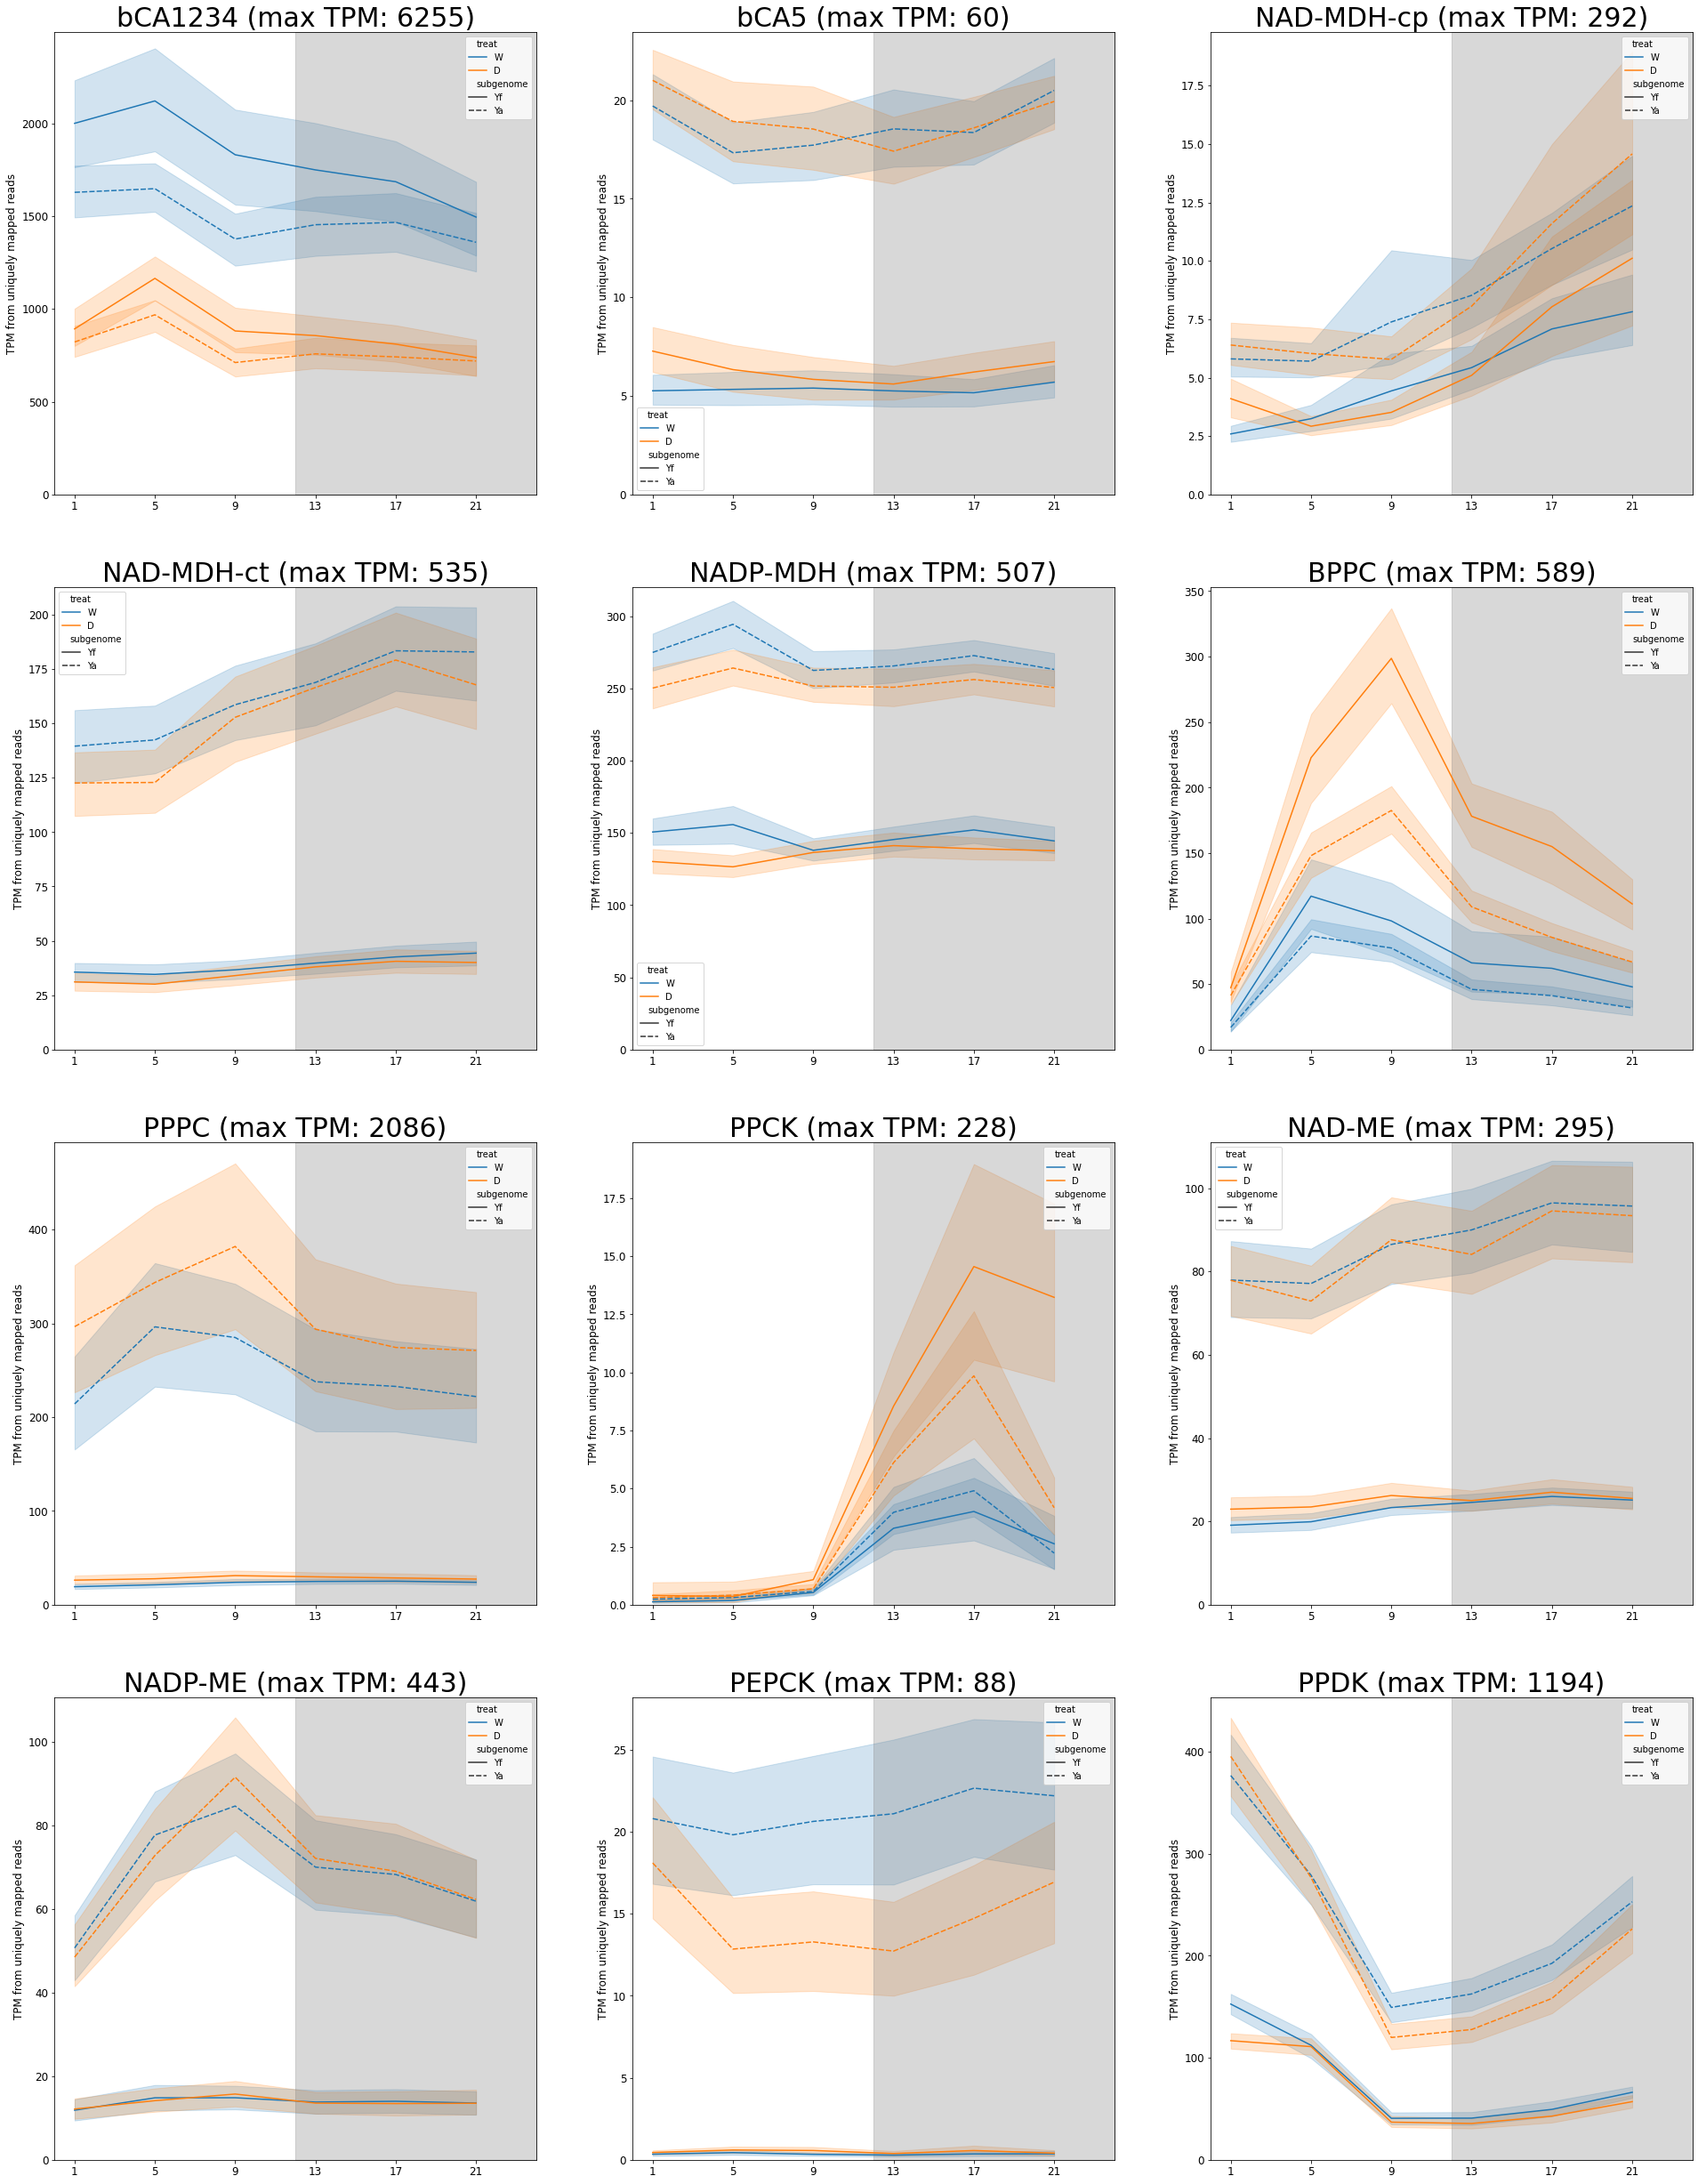

In [23]:
fig,ax = plt.subplots(nrows=4,ncols=3,figsize=(33,44))
c=0
r=0
for i in camts2["gene_abbr"].unique():
    plotdf = plottpm_genefamily(zttpm,i,camts2)
    plot_profile(i,plotdf,(r,c),ax,30,"")
    if c<2:
        c+=1
    else:
        c=0
        r+=1
        
plt.savefig("./cam_gene_family_profiles.png",dpi=200,bbox_inches="tight")
plt.savefig("./cam_gene_family_profiles.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./cam_gene_family_profiles.svg",dpi=200,bbox_inches="tight")

In [20]:
# next: plot profile of each individual gene in each gene family
## need to modify some functions for this
# rework plottpm similarly
def plottpm_singlegene(tpm,geneid):
    cols = ["sample_name","genotype","treat","ZT",geneid]
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=geneid)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    return plong.sort_values(by="treat",ascending=False)

In [21]:
def plot_profile_gene(titletext,cpdf,axc,a,tf,log=False):
    # pull max TPM (out of curiosity)
    maxtpm = int(round(max(cpdf["TPM"]),0))
    
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext+" (max TPM: "+str(maxtpm)+")",fontsize=tf)

In [22]:
# create a function to plot a given gene family
def plot_genefam_allgenes(genefam,tpm=zttpm,camdf=camts2):
    # subset to only the given gene family
    gfdf = camdf[camdf["gene_abbr"]==genefam]
    geneids = list(gfdf["GeneID"].unique())
    genedict = {}
    for i in range(len(gfdf.index)):
        genedict[gfdf.iloc[i,0]] = gfdf.iloc[i,5]
    
    # set up number of subplots (rows & columns)
    nplots = len(geneids)
    if (nplots % 2 == 0 and nplots/2 < 3):
        nc = 2
        nr = int(nplots/2)
    elif nplots % 3 == 0:
        nc = 3
        nr = int(nplots/3)
    else:
        nc = 3
        nr = int((nplots/3)+1)
            
    # set up w & h depending on nc & nr
    w = 10*nc
    h = 10*nr
    # set up font sizes depending on nc & nr
    if nc==3:
        stf = 36
        tf = 24
    else:
        stf = 26
        tf = 20
        
    fig,ax = plt.subplots(nrows=nr,ncols=nc,figsize=(w,h))
    
    r=0
    j=0
    
    # plot each gene from the gene family
    for g in geneids:
        p=plottpm_singlegene(tpm,g)
        plot_profile_gene(genedict[g],p,(r,j),ax,tf)
        
        if j!= nc-1:
            j+=1
        else:
            j=0
            r+=1
            
    # remove extraneous empty plot axes
    if nplots!=(nr*nc):
        fig.delaxes(ax[nr-1,nc-1])
        if (nr*nc)-nplots==2:
            fig.delaxes(ax[nr-1,nc-2])
            
    plt.suptitle(genefam+" Profiles",fontsize=stf,y=0.915)
    
    filename = "./cam_genefamily_profiles/"+genefam
    plt.savefig(filename+".png",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".svg",dpi=200,bbox_inches="tight")

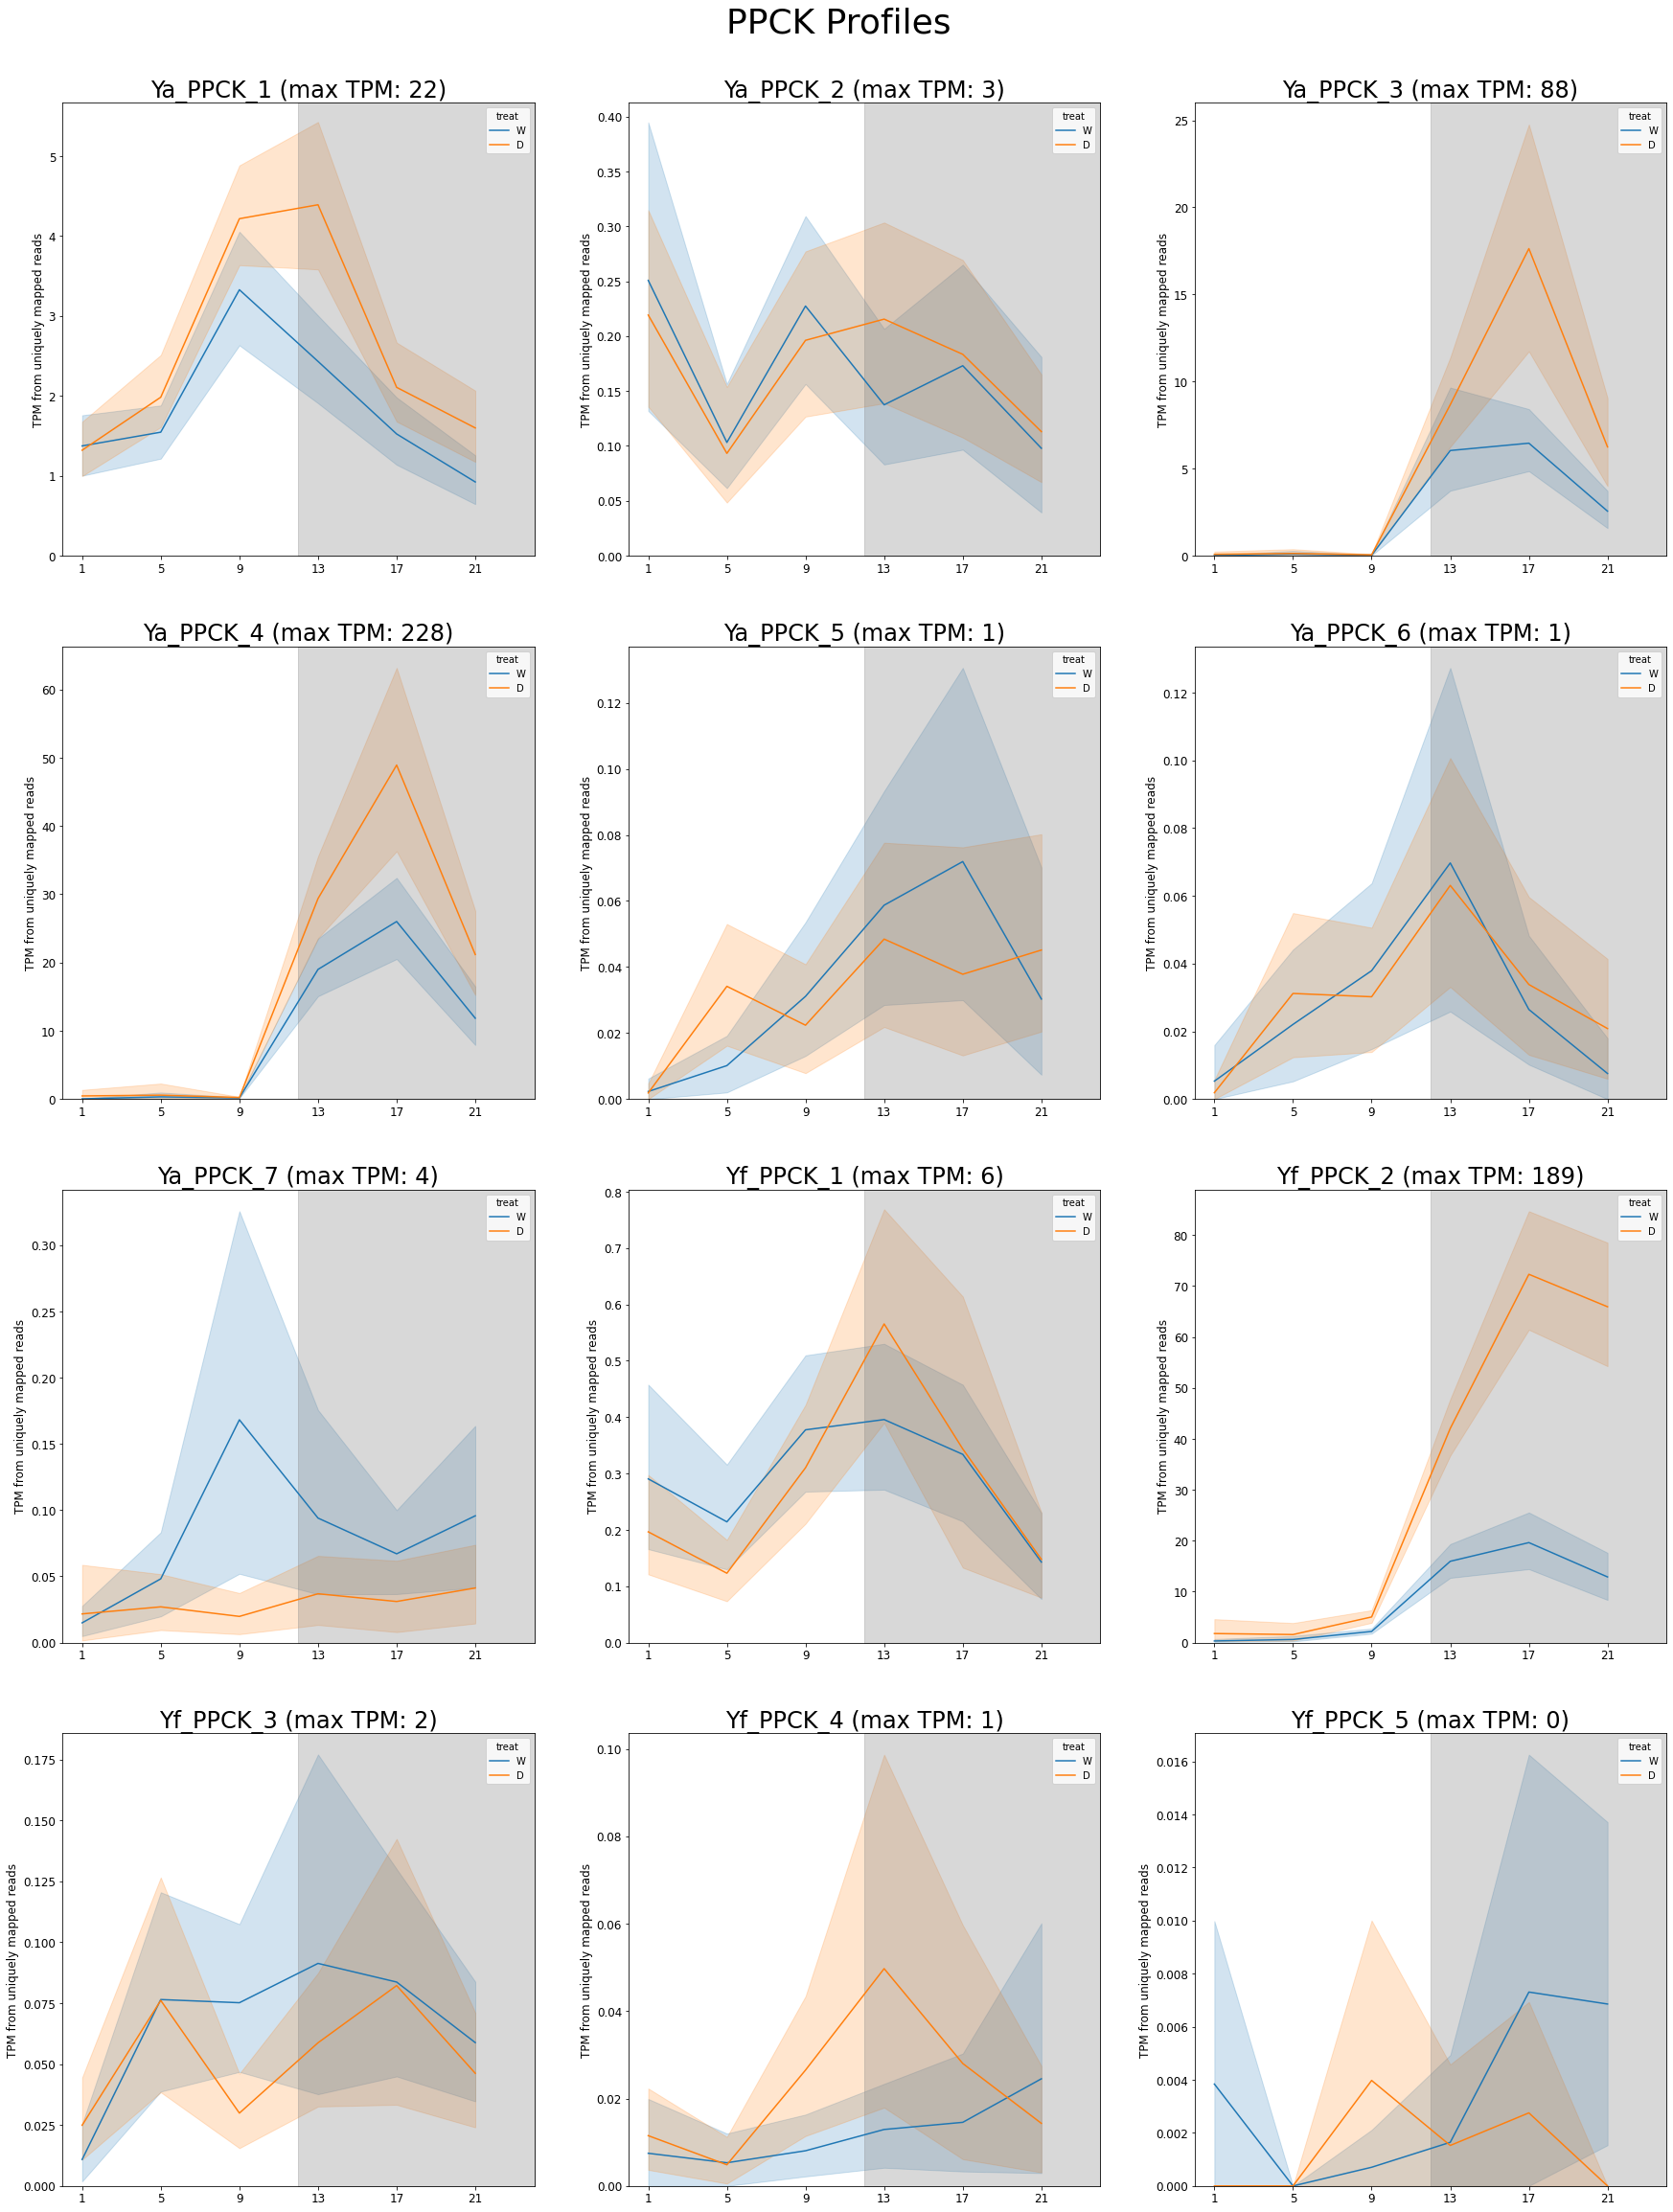

In [33]:
# a test: PPCK
plot_genefam_allgenes("PPCK")

In [23]:
# instead of plotting each individual gene in each family: plot each family on a per-genotype basis
## first, based on SNP PCA: set up a dict of which genotypes group together
gtgroups = {
    "top":["51","2AB","1AB","45","15"],
    "bottom":["46","Eudy","70","48","G","43","52","18","19","20","53"]
}

In [24]:
mid = []
for g in zttpm["genotype"].unique():
    if (g not in gtgroups["top"] and g not in gtgroups["bottom"]):
        mid.append(g)

In [29]:
gtgroups["middle"] = mid

In [25]:
# for a given gene family make a set of plots with each genotype on a single plot (split by treatment & subgenome)
## this will be 22 plots in 4 columns, 5 rows
def plot_all_gt(genefam):
    fig,ax = plt.subplots(nrows=5,ncols=4,figsize=(44,66))

    r=0
    c=0

    for k in ["top","middle","bottom"]:
        gtl = gtgroups[k]
        for i in gtl:
            if i in list(zttpm["genotype"].unique()):
                gttpm = zttpm[zttpm["genotype"]==i]
                ptpm = plottpm_genefamily(gttpm,genefam,camts2)
                plot_profile("Genotype "+i,ptpm,(r,c),ax,24,"")

                if c!= 3:
                    c+=1
                else:
                    c=0
                    r+=1
    
    plt.suptitle(genefam+" Genotype Profiles",fontsize=36,y=0.915)
    
    if not os.path.exists("./profiles_by_genotype/"):
        os.makedirs("./profiles_by_genotype/")
    
    filename = "./profiles_by_genotype/"+genefam+"_profiles_by_genotype"
    plt.savefig(filename+".png",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".pdf",dpi=200,bbox_inches="tight")
    plt.savefig(filename+".svg",dpi=200,bbox_inches="tight")

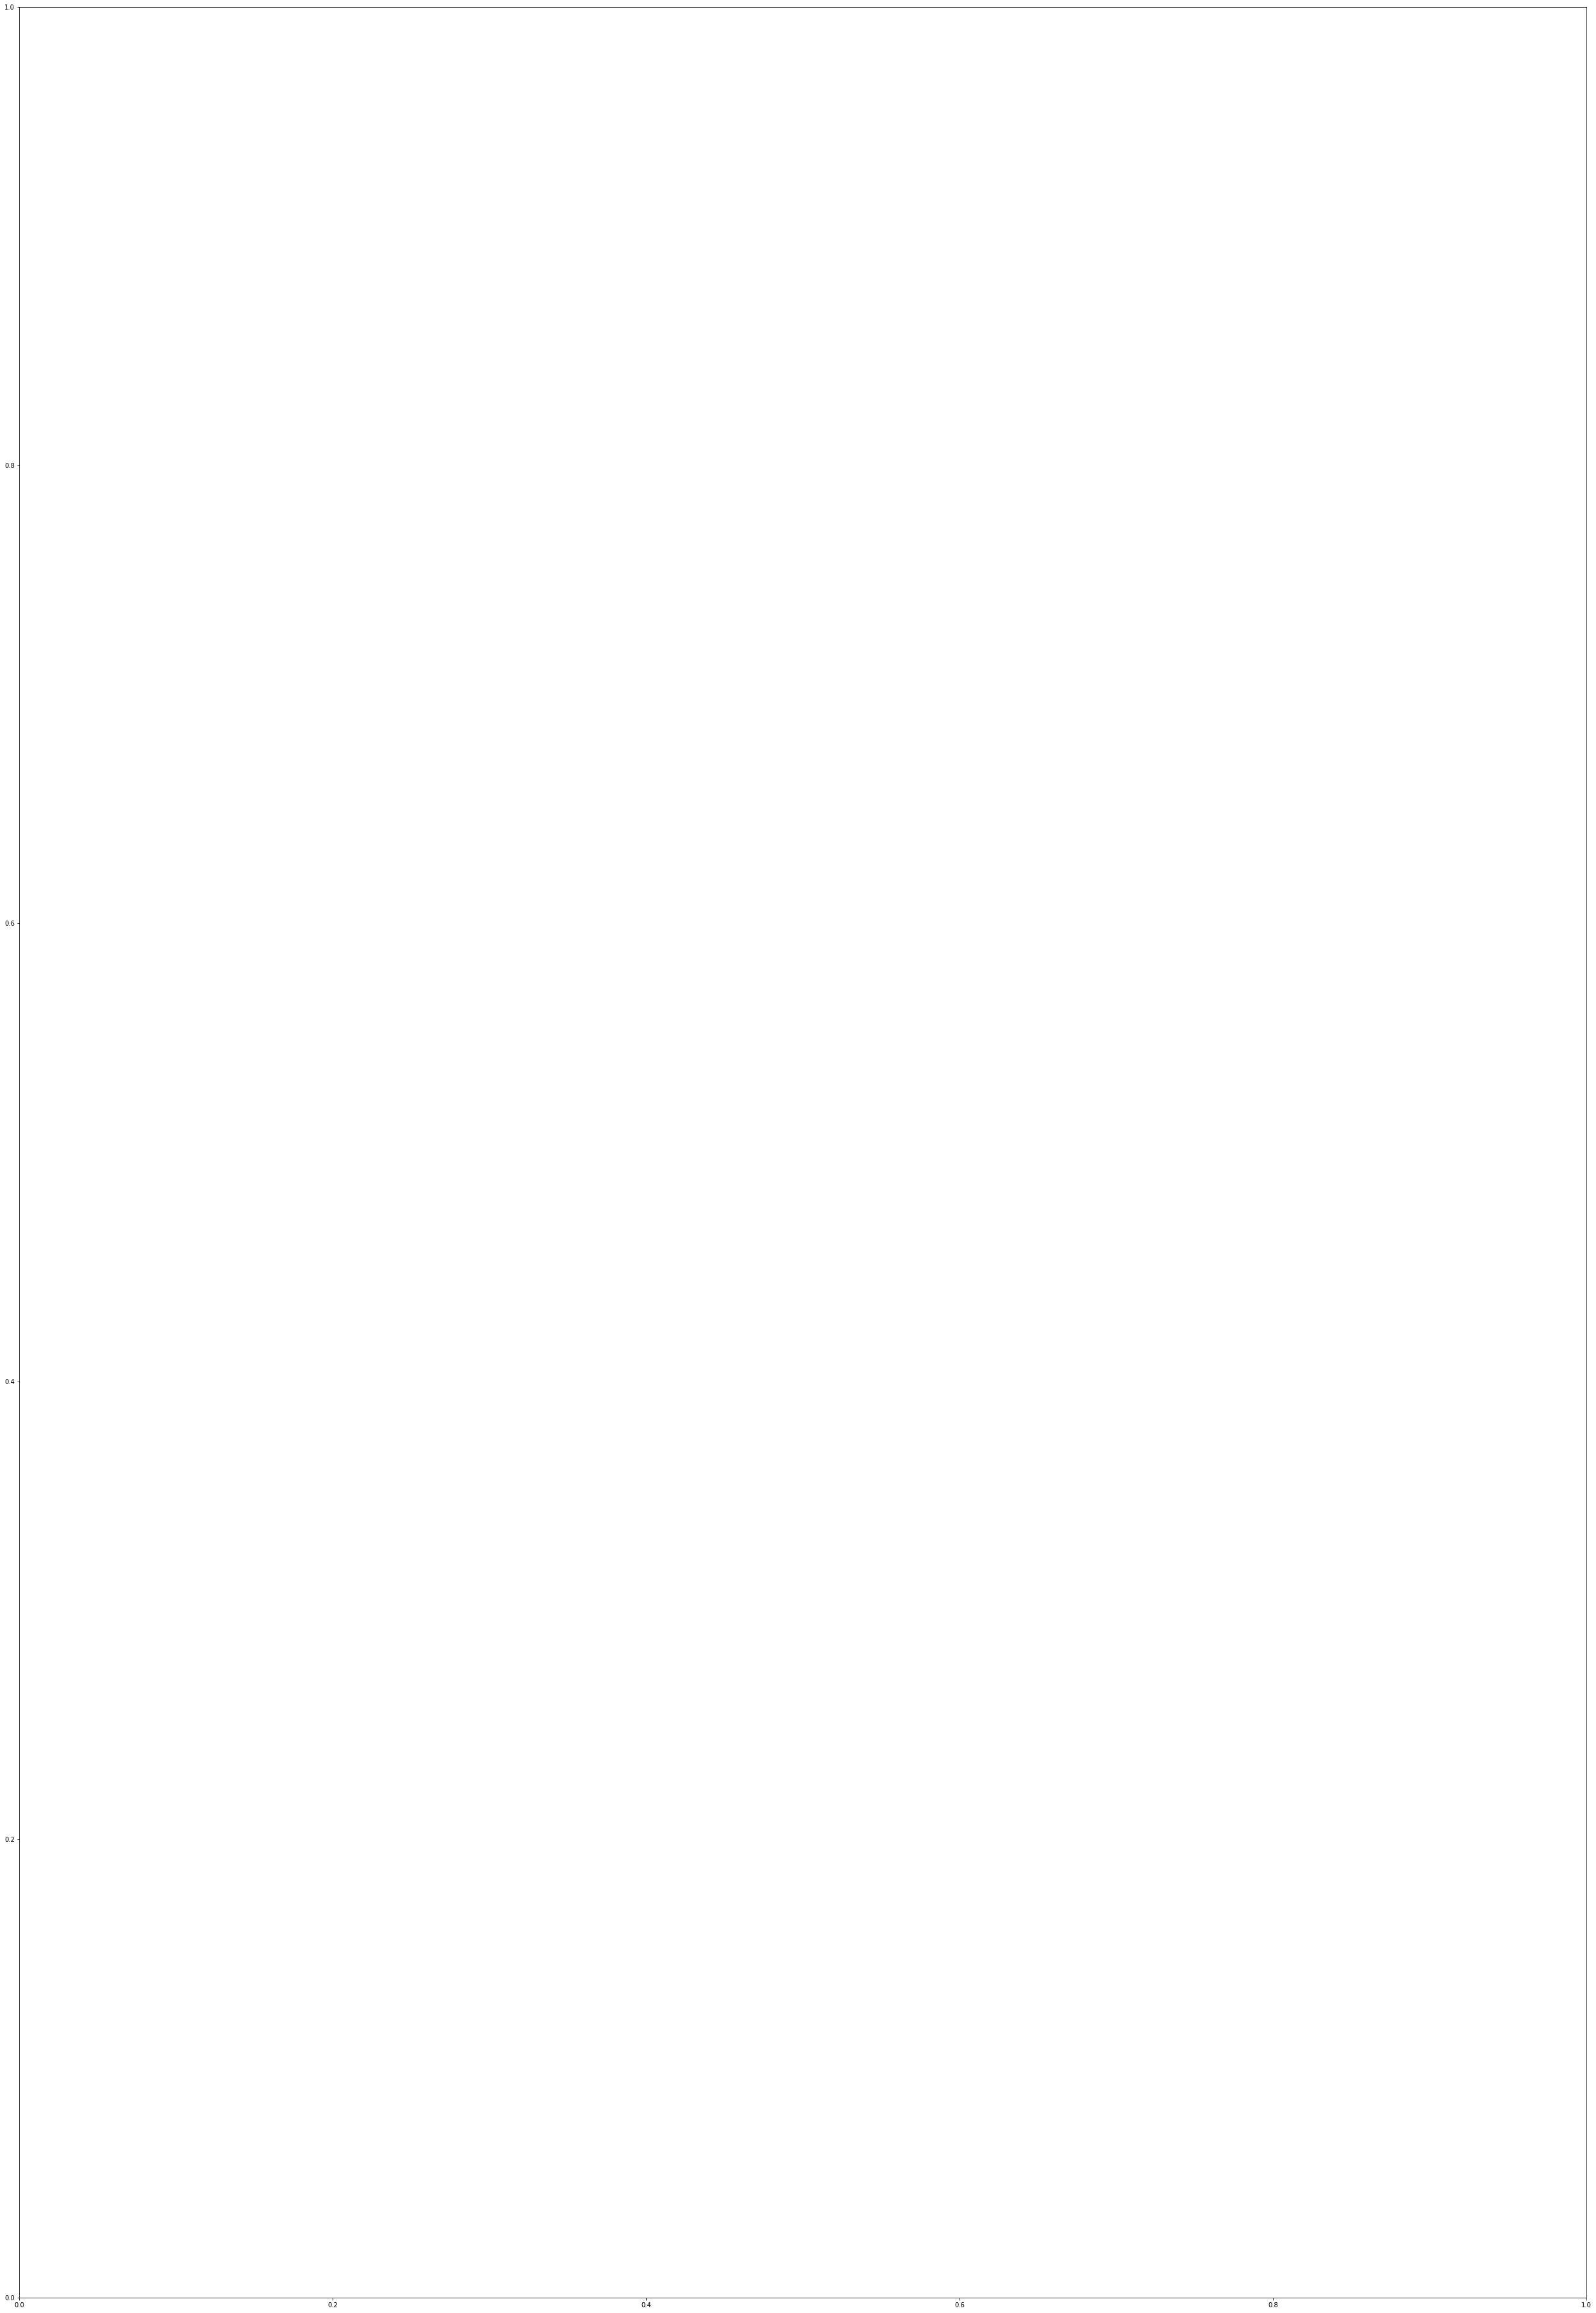

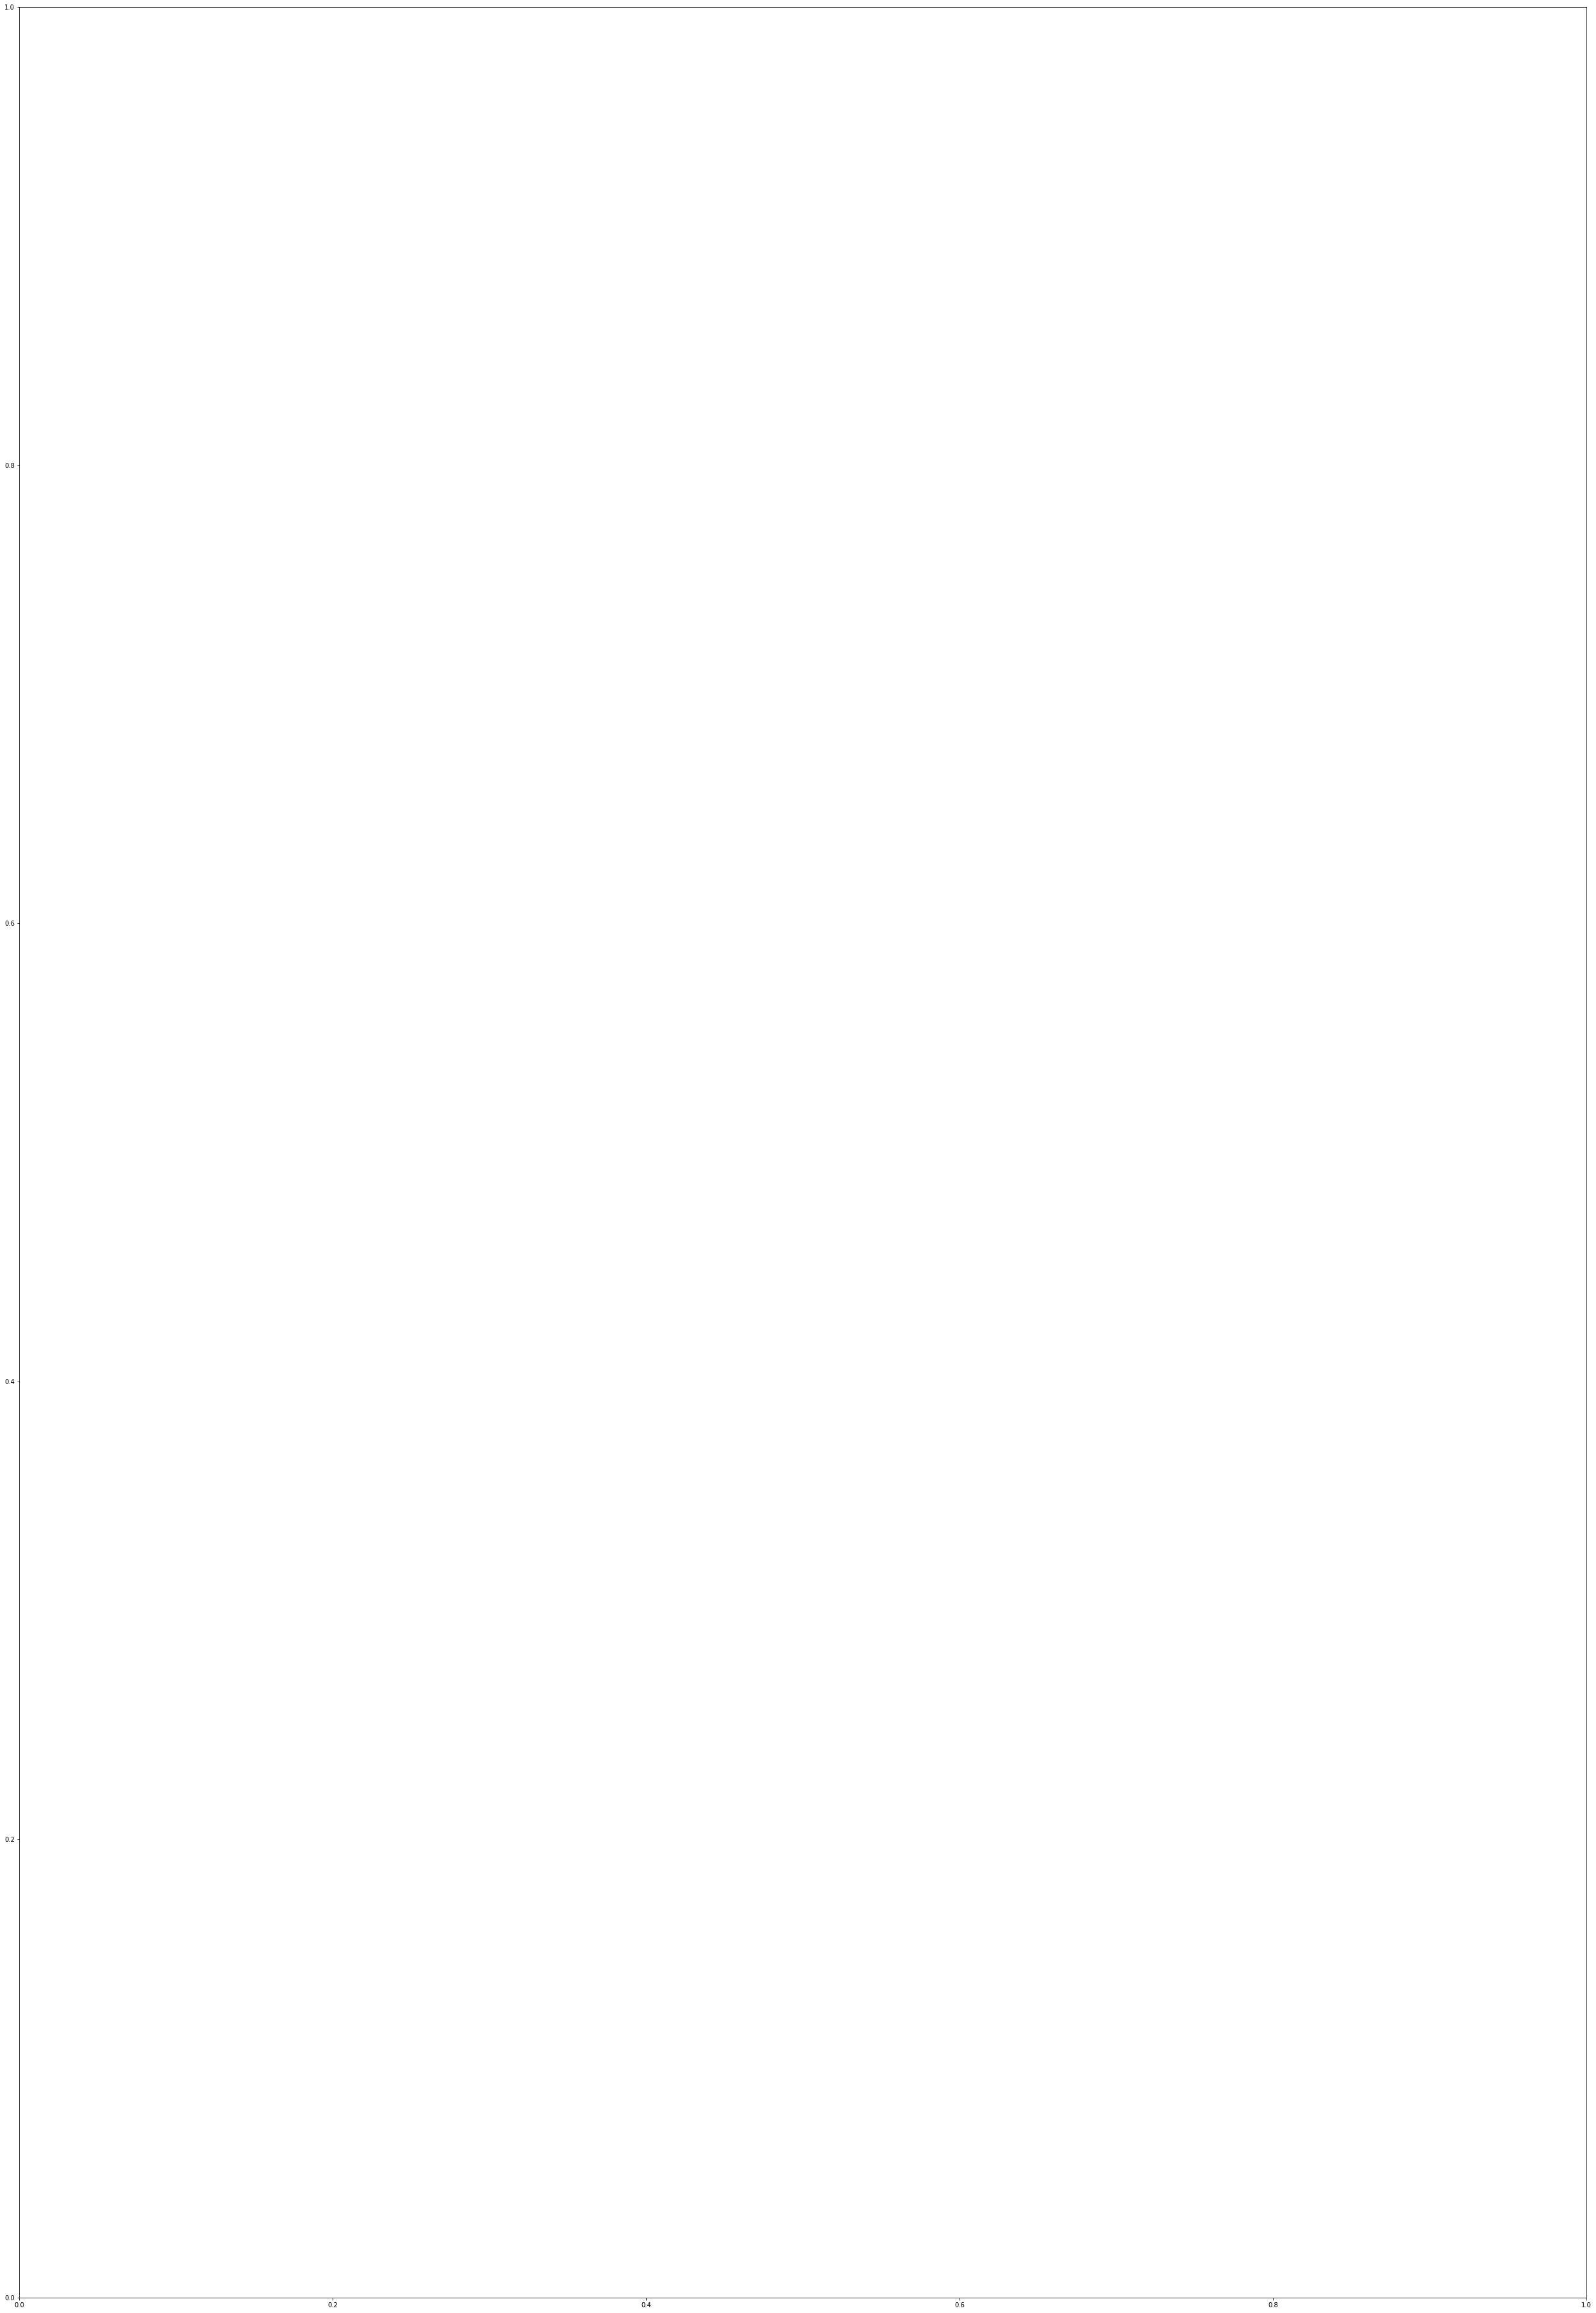

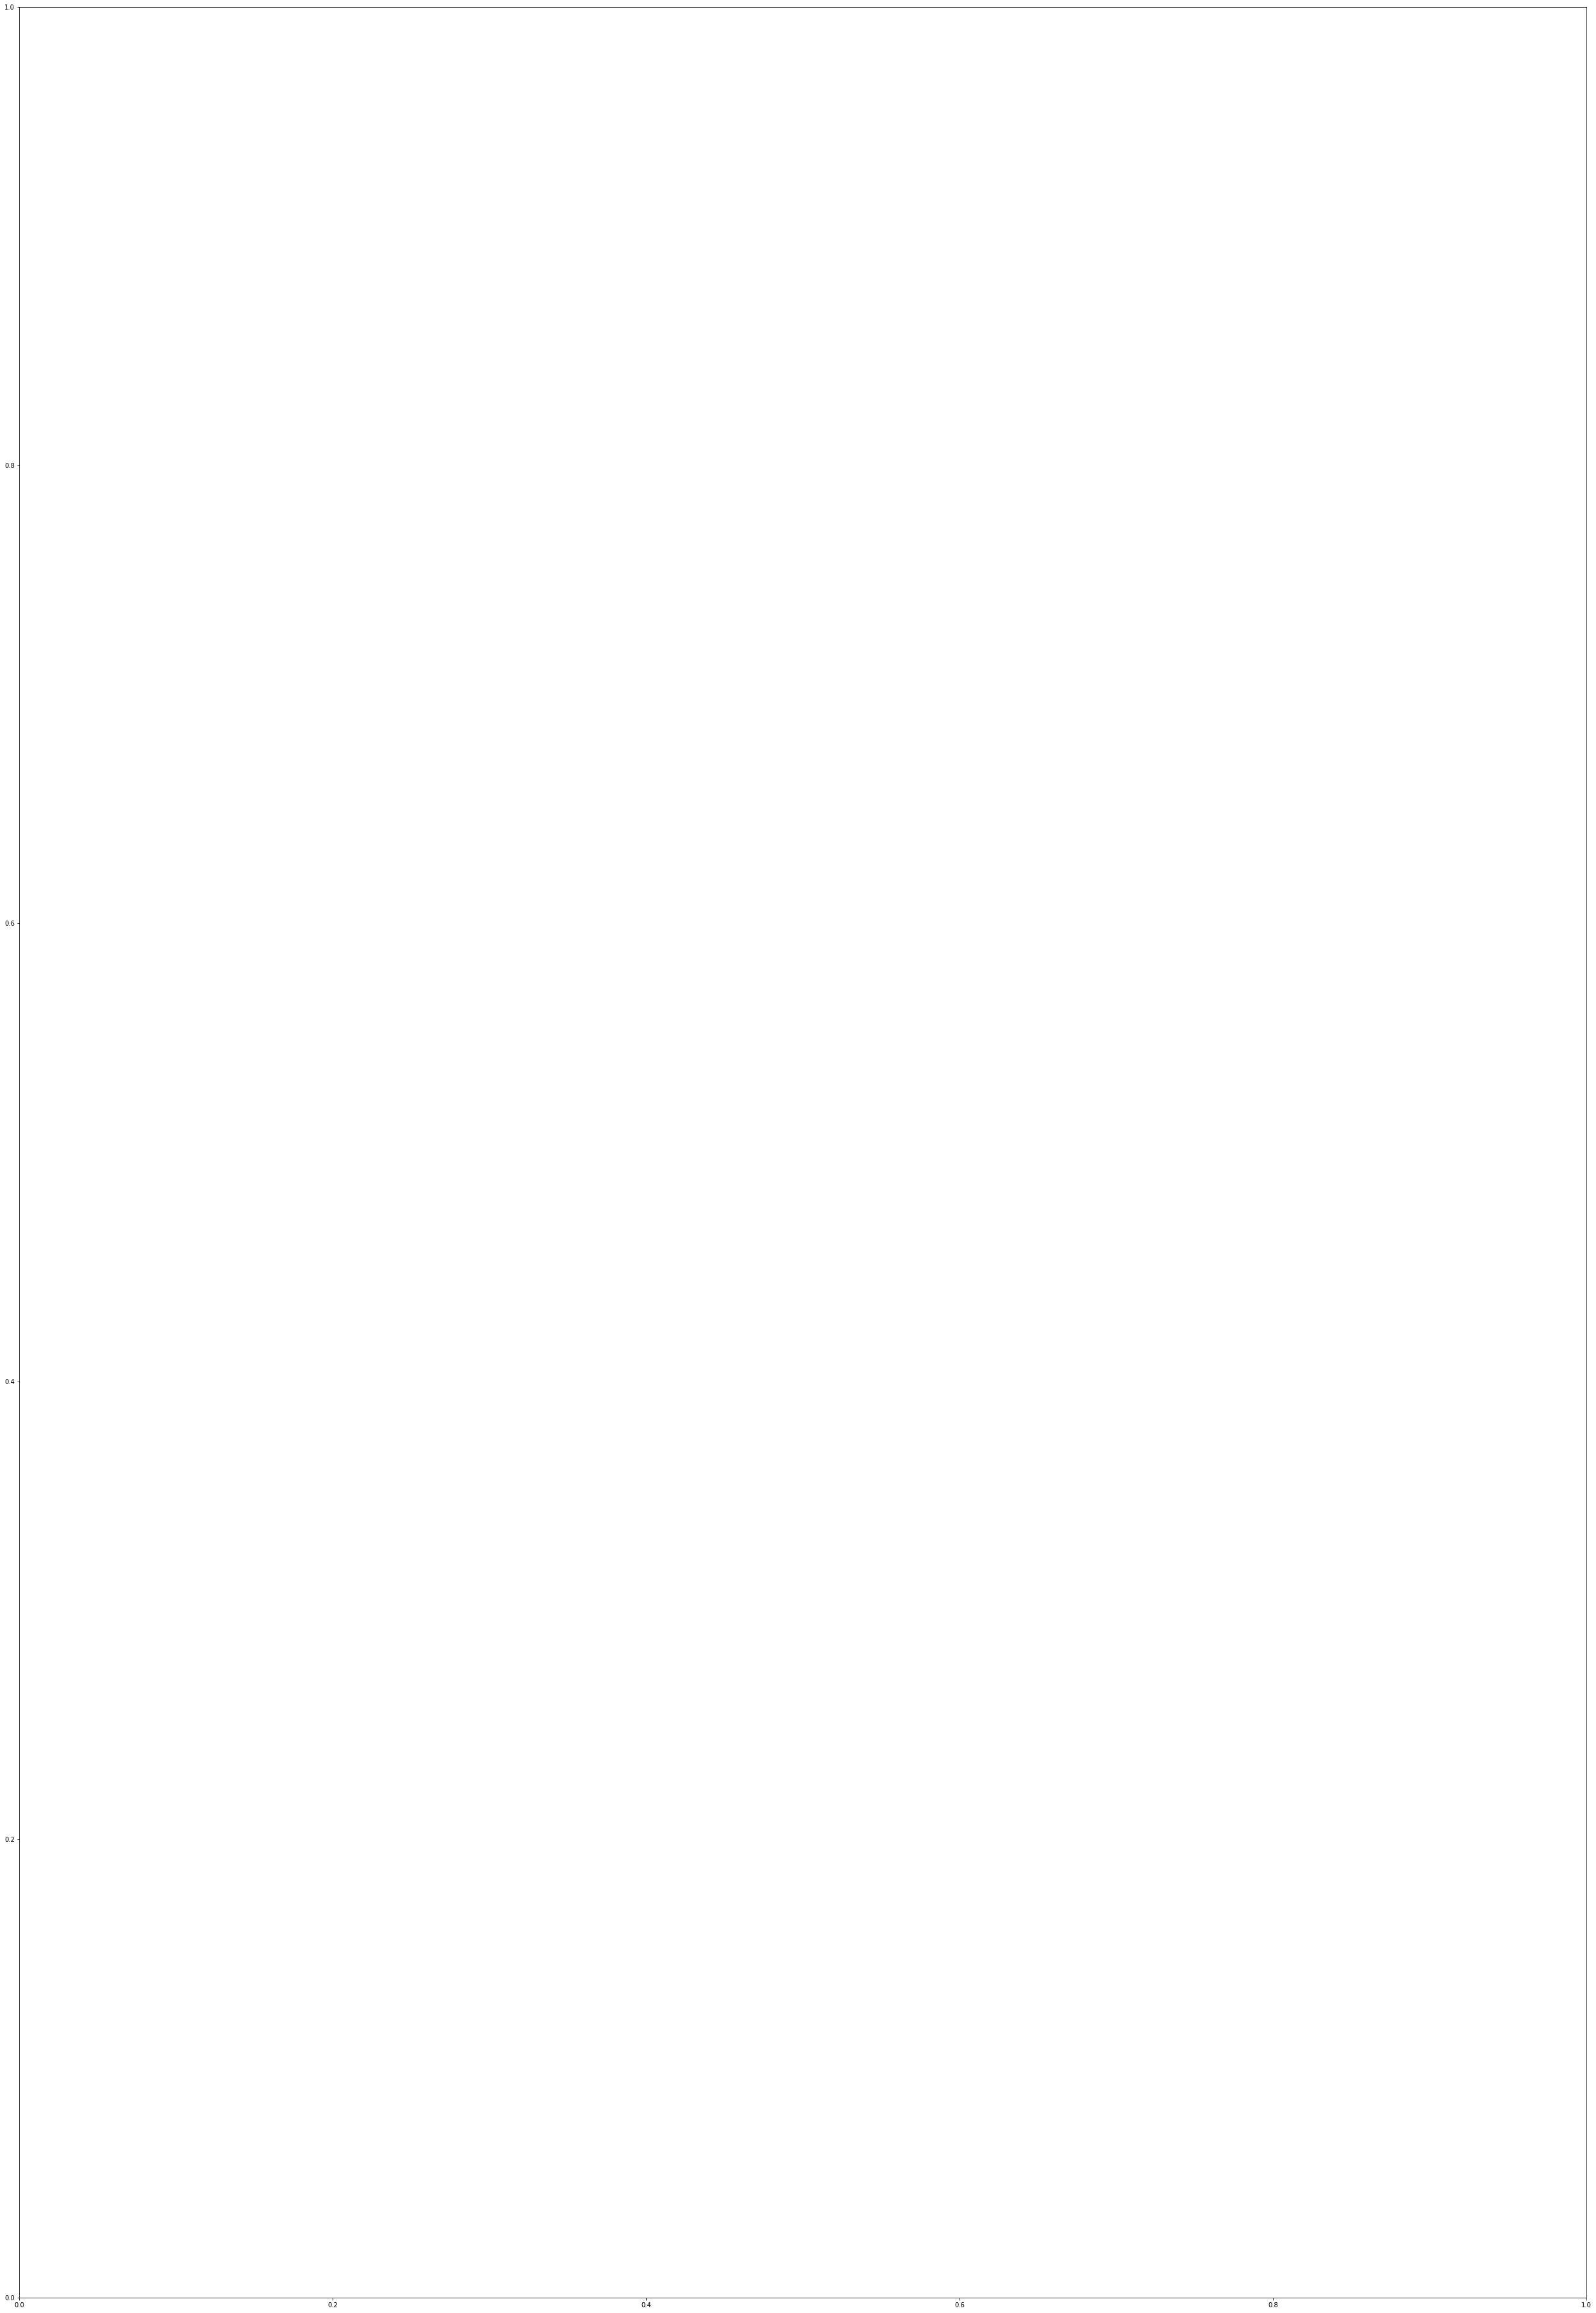

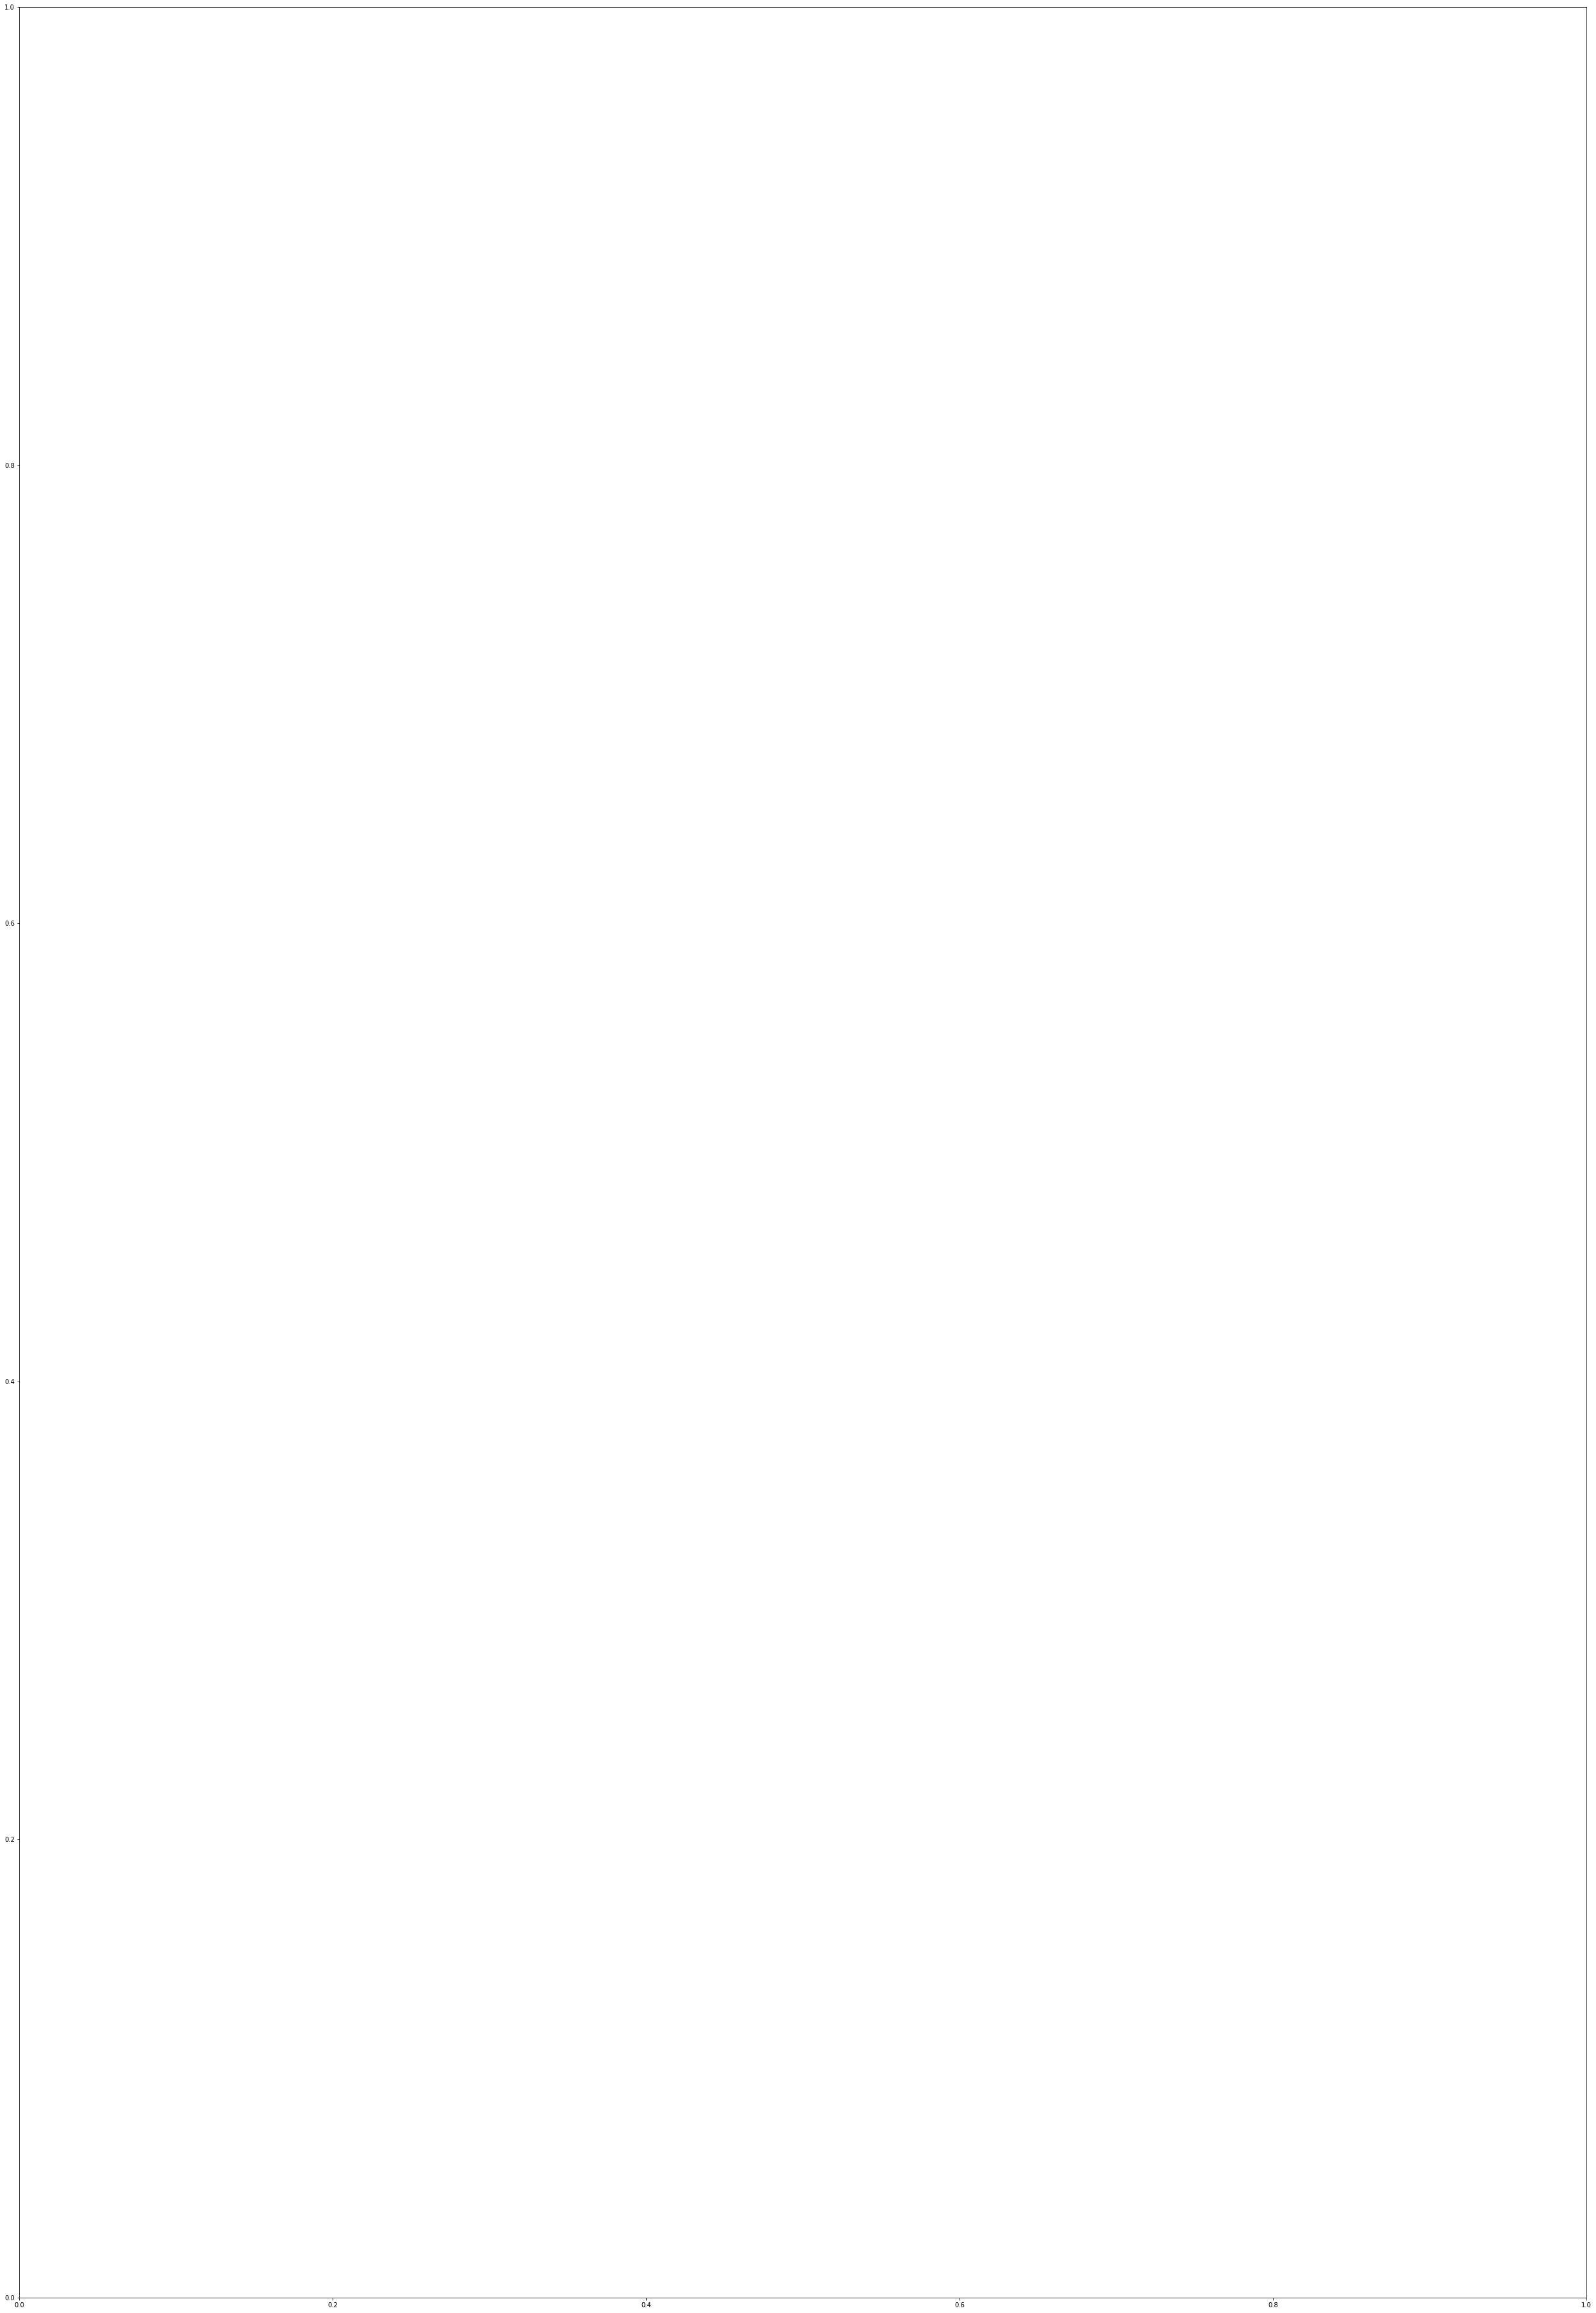

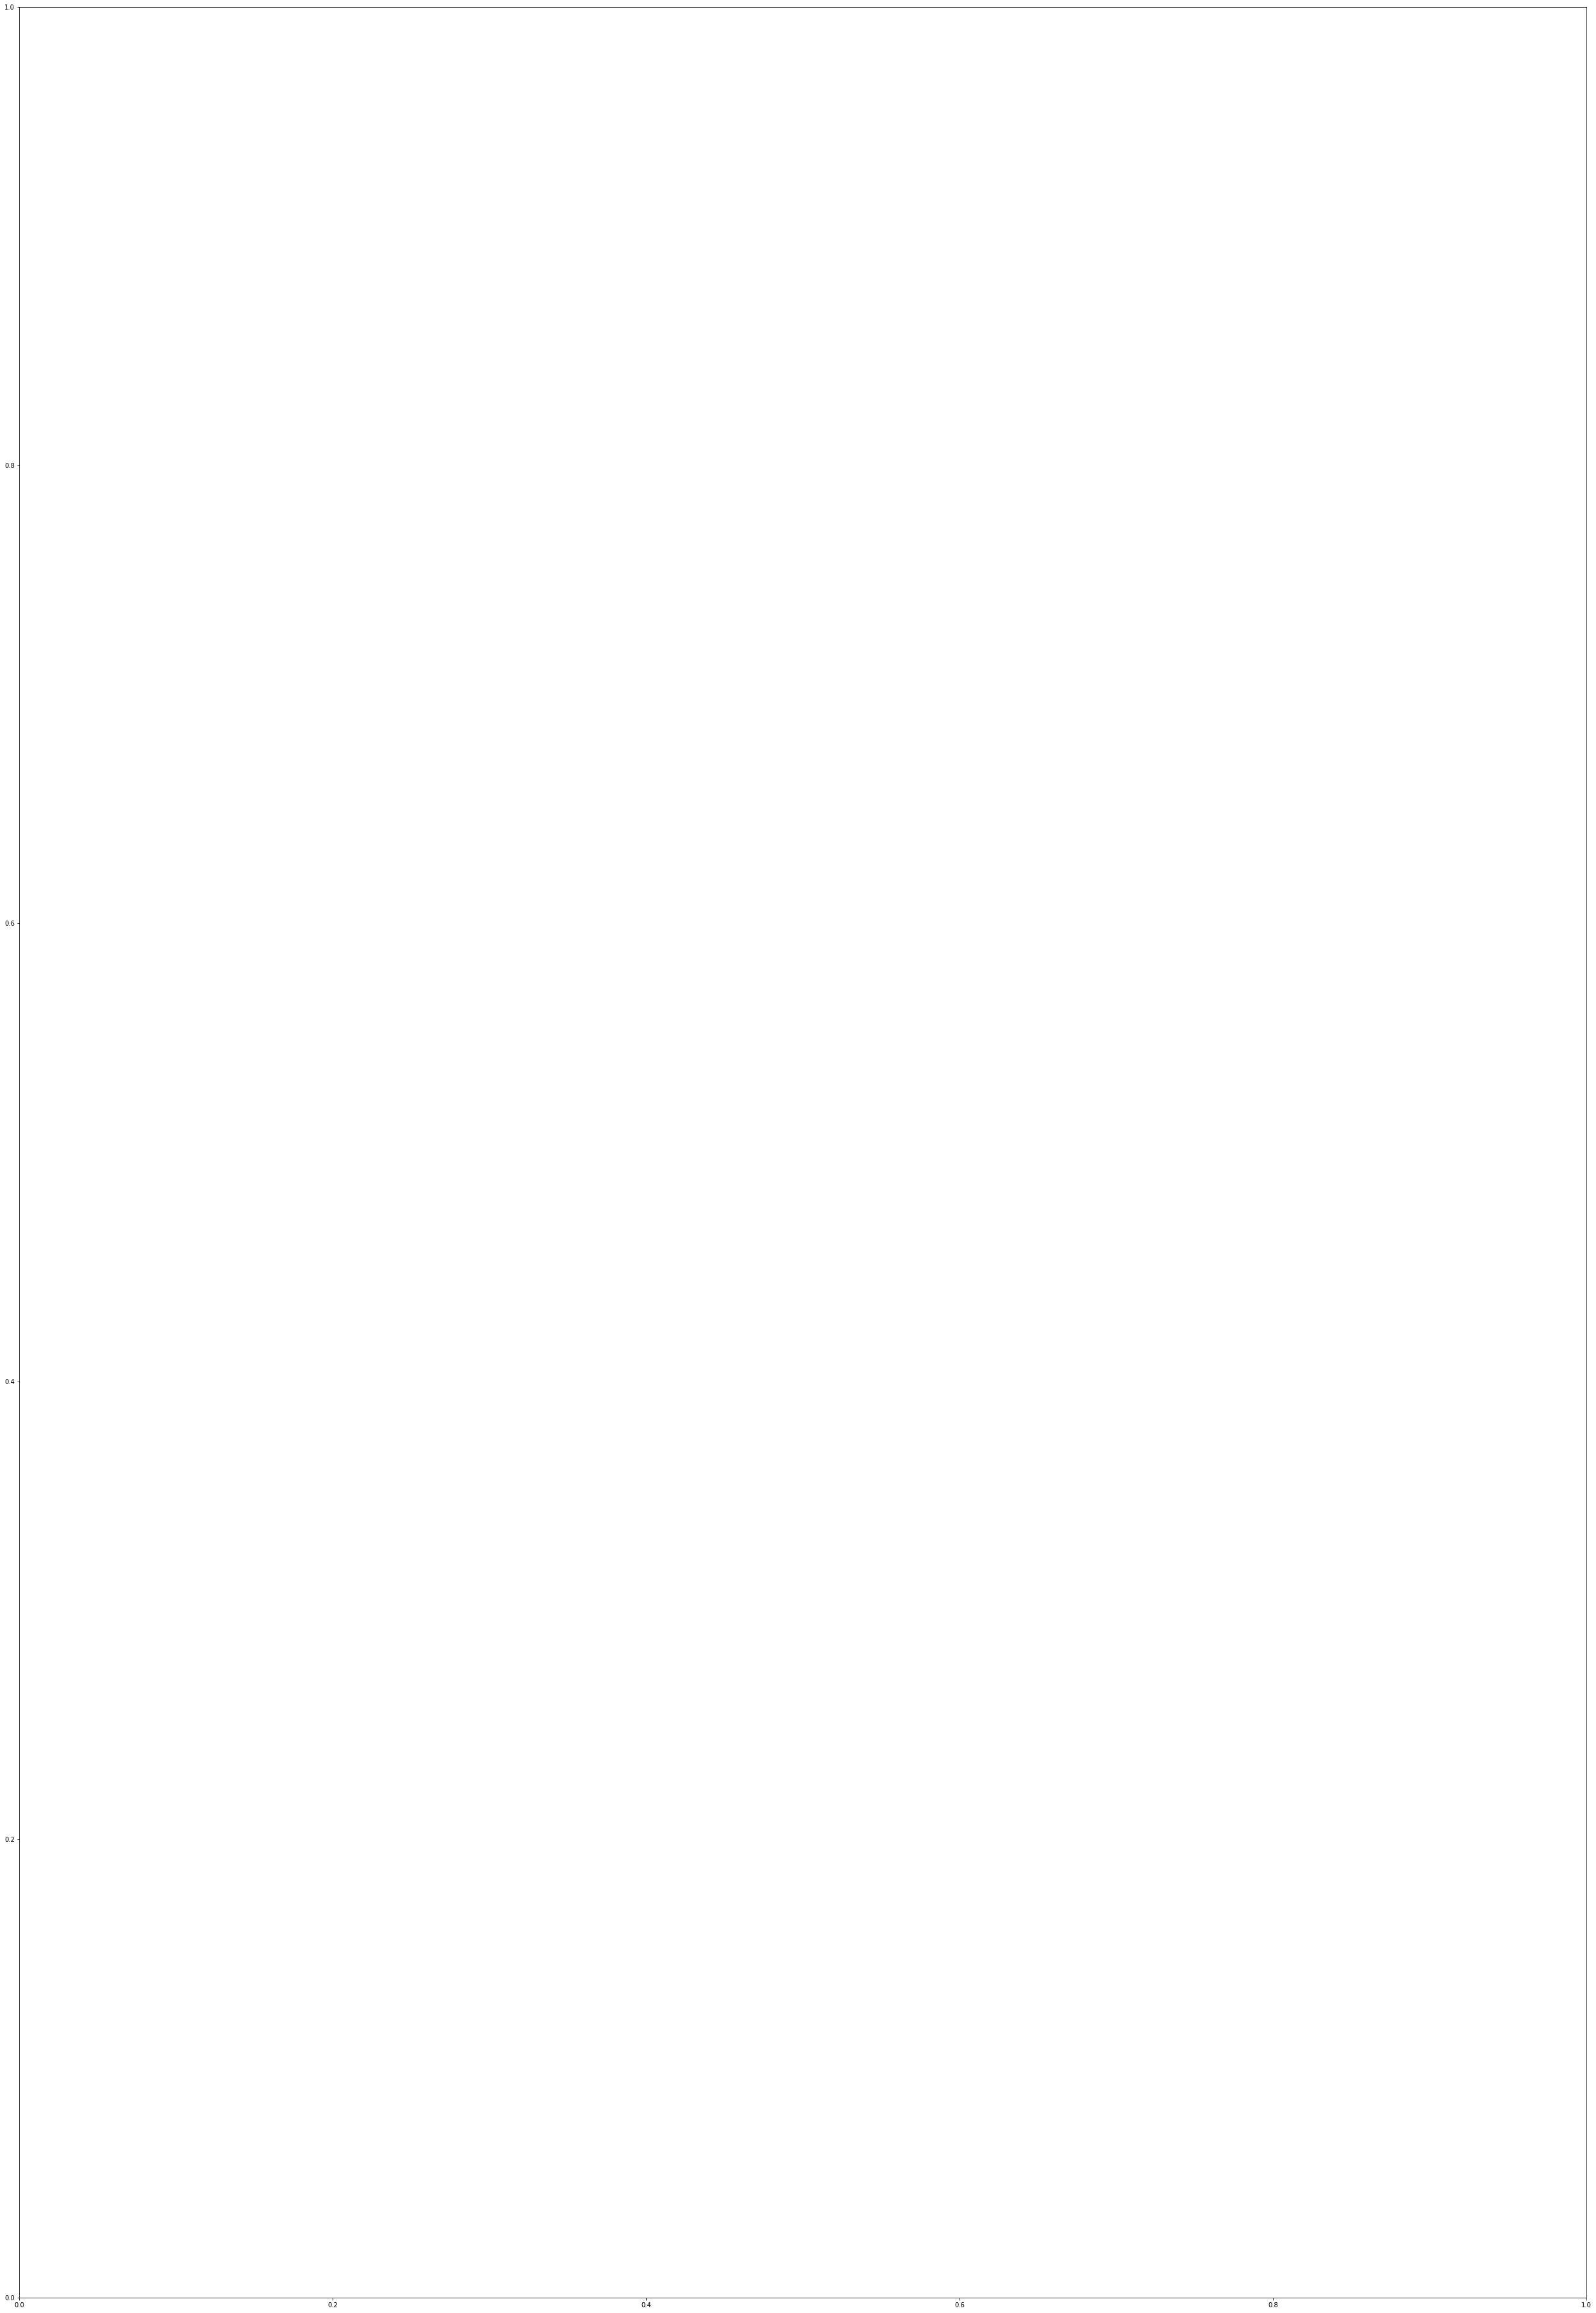

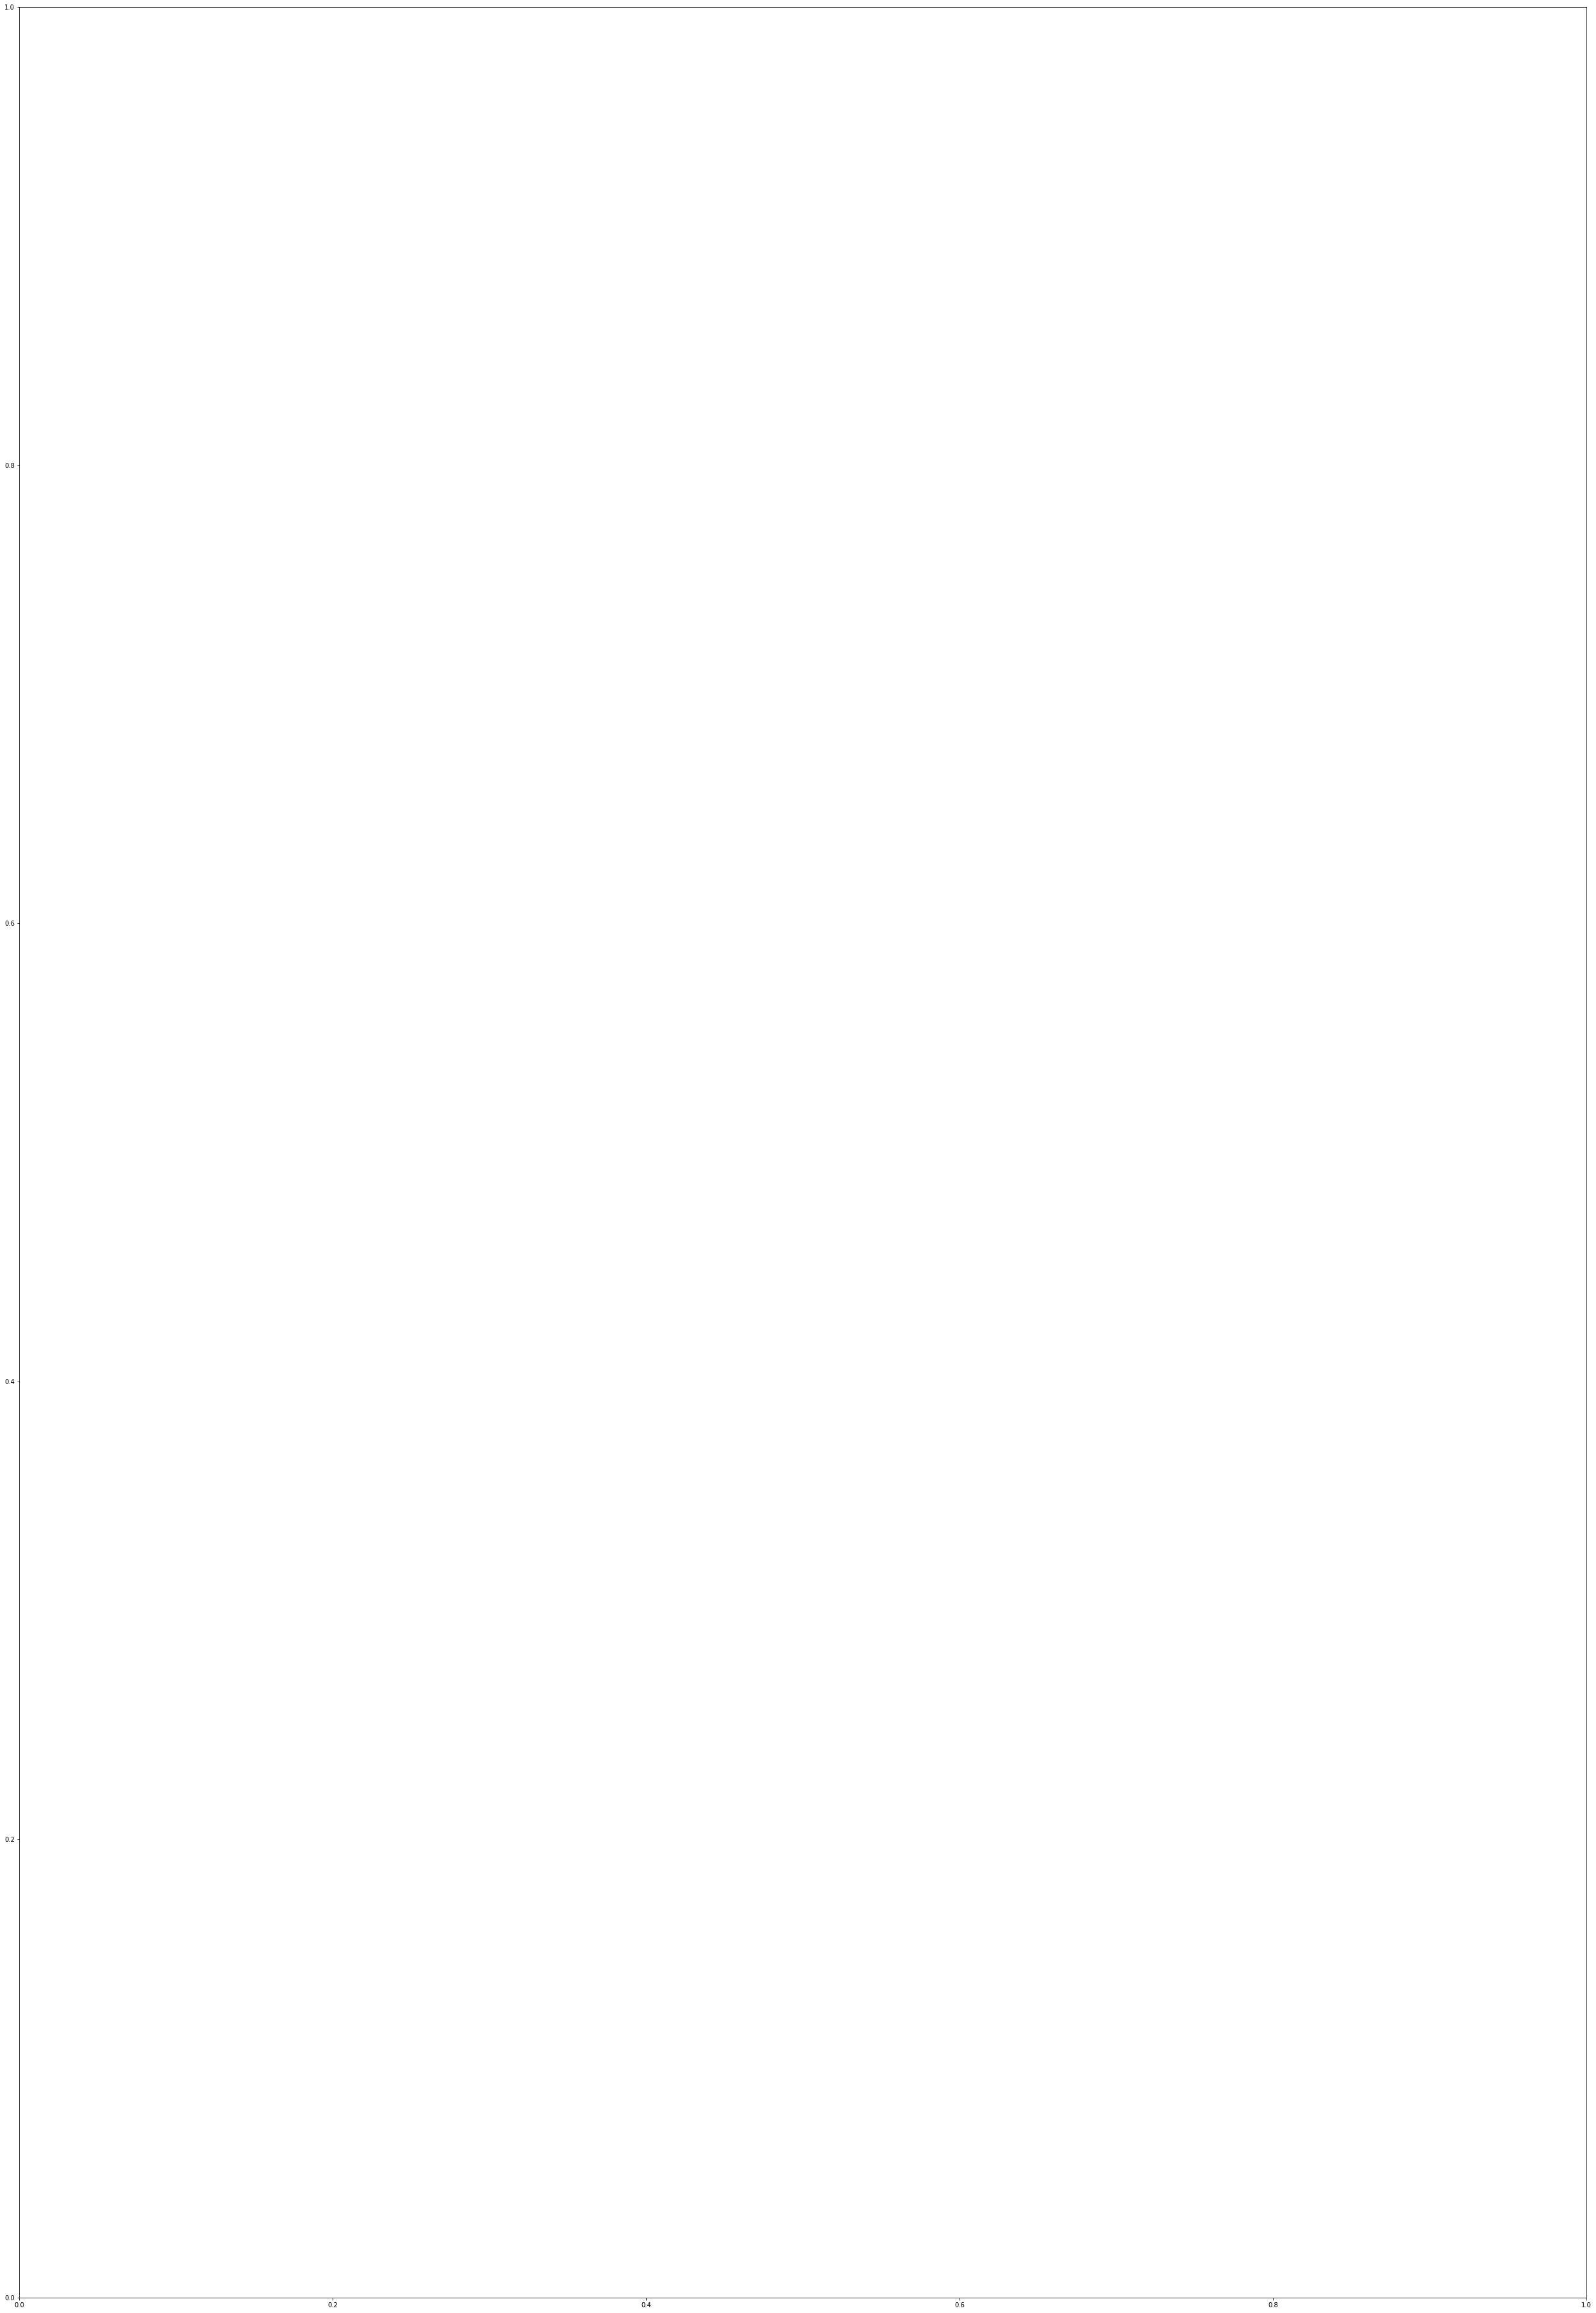

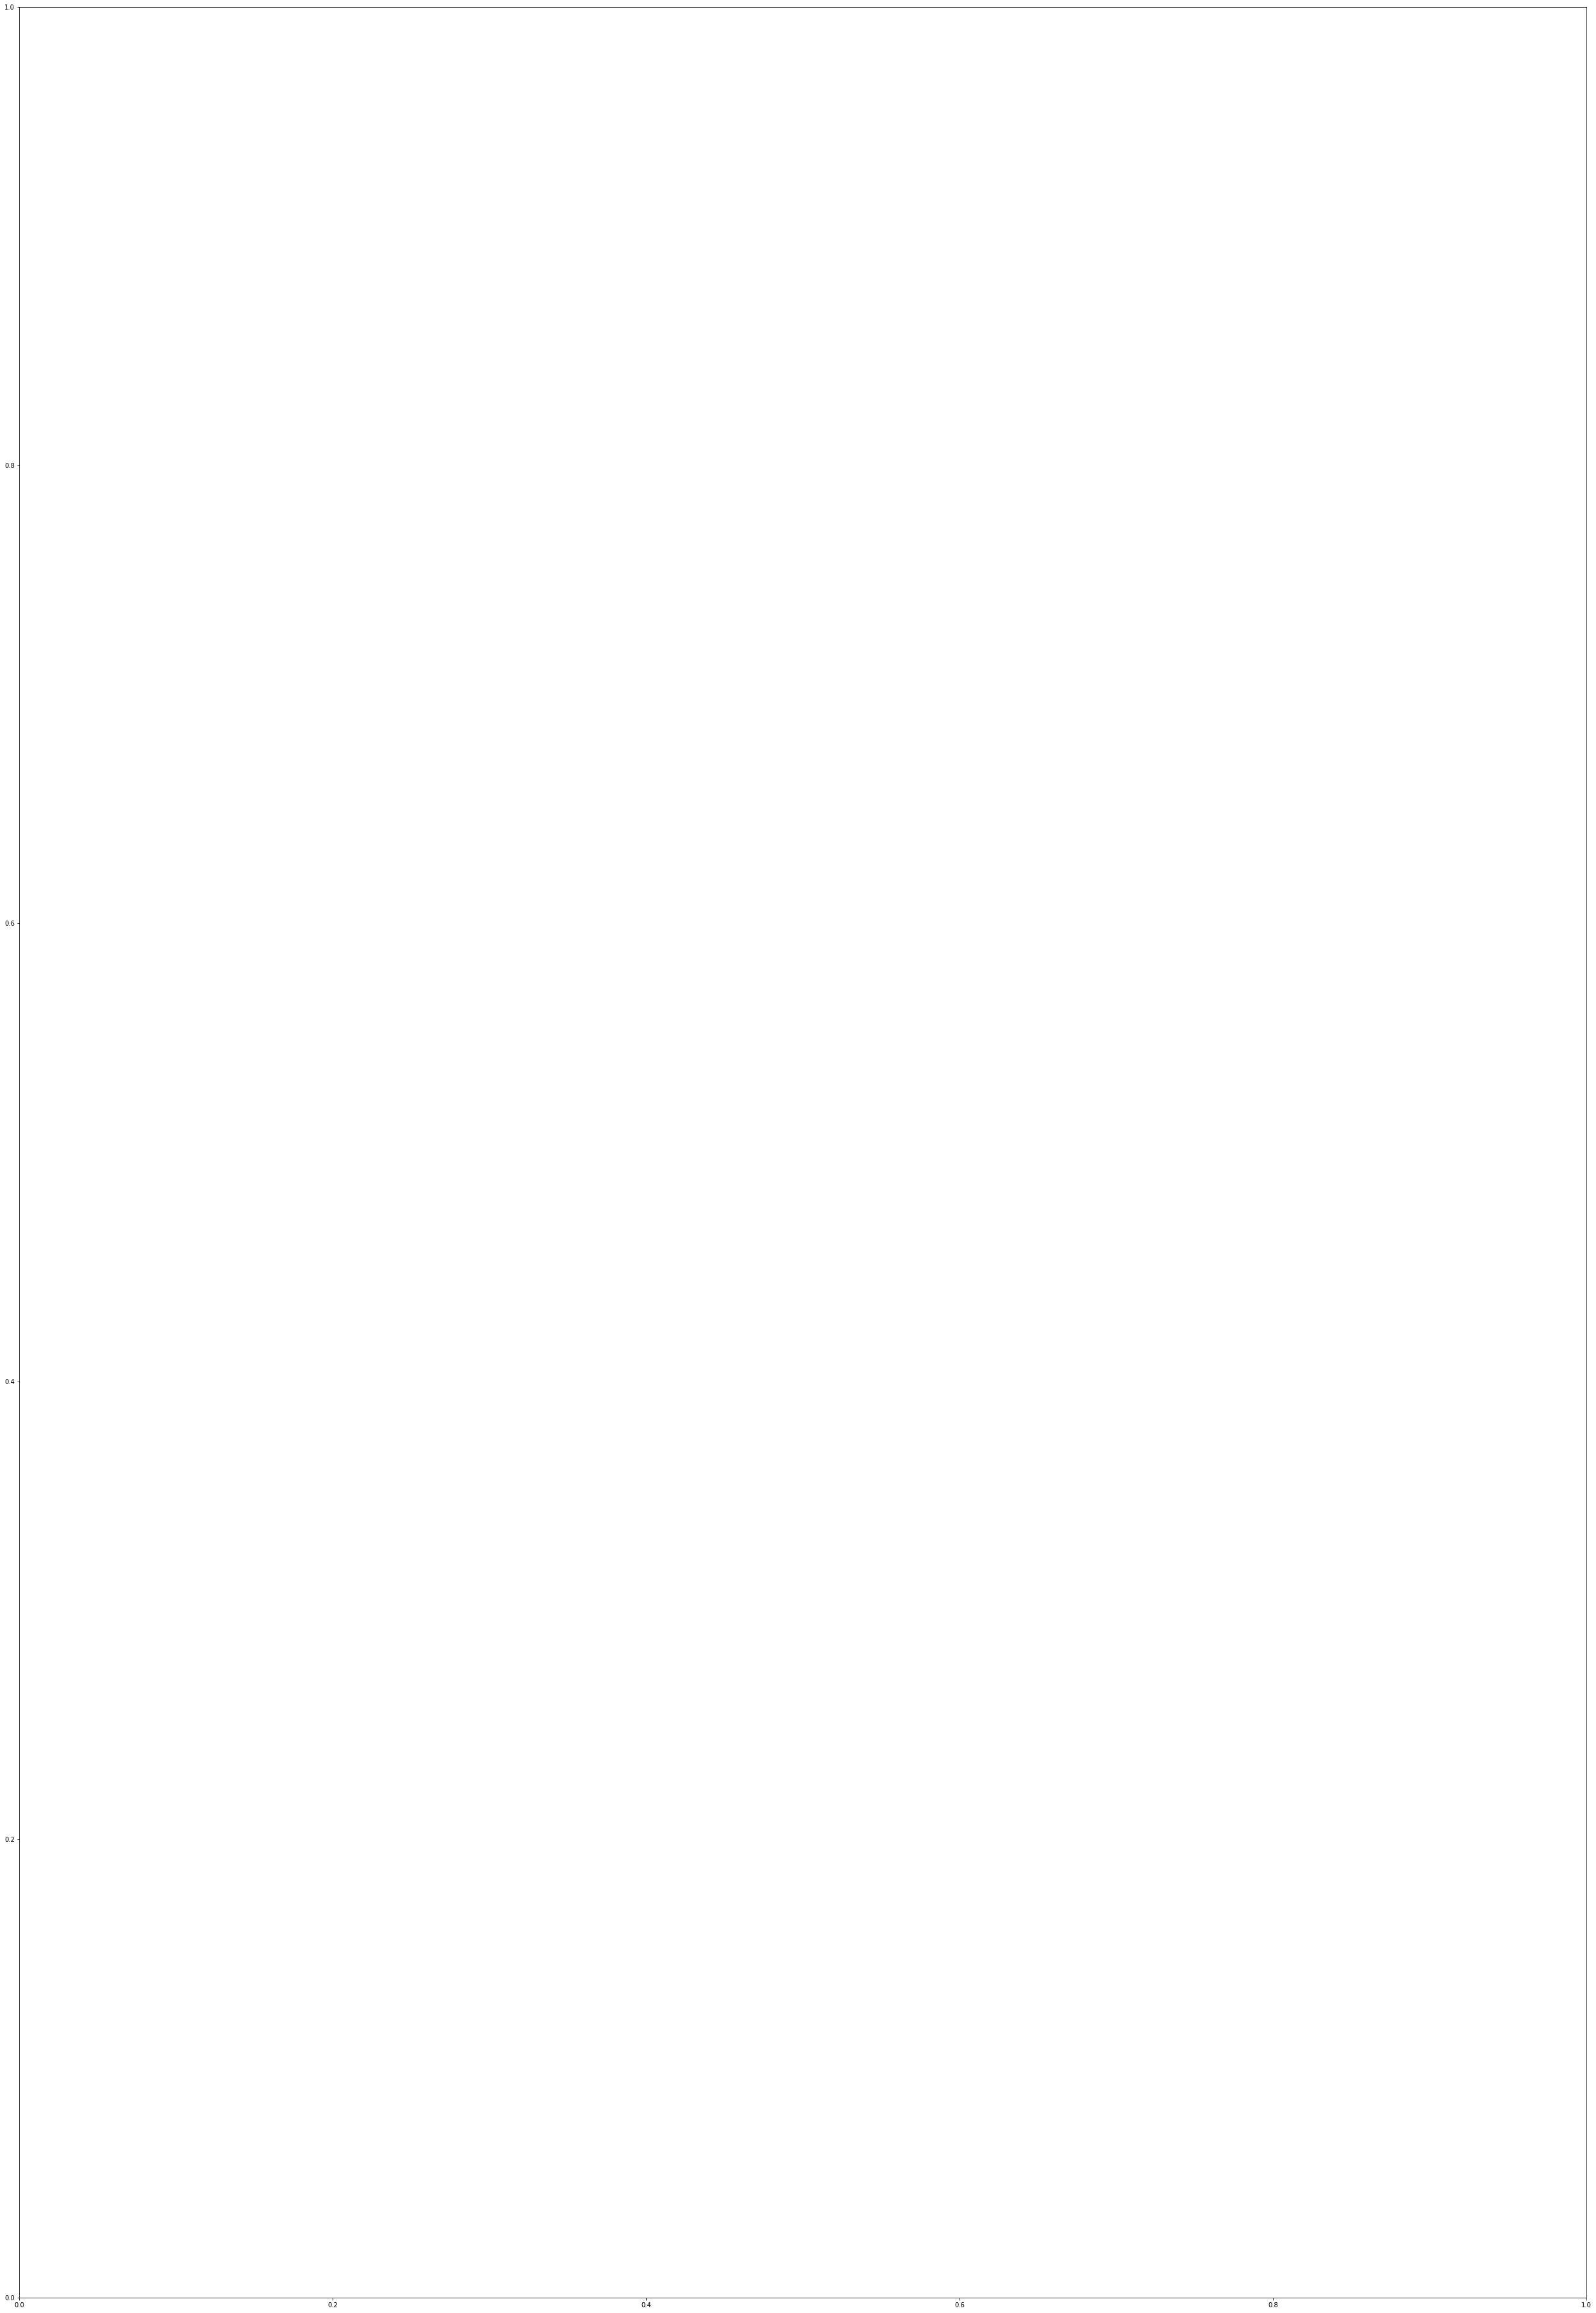

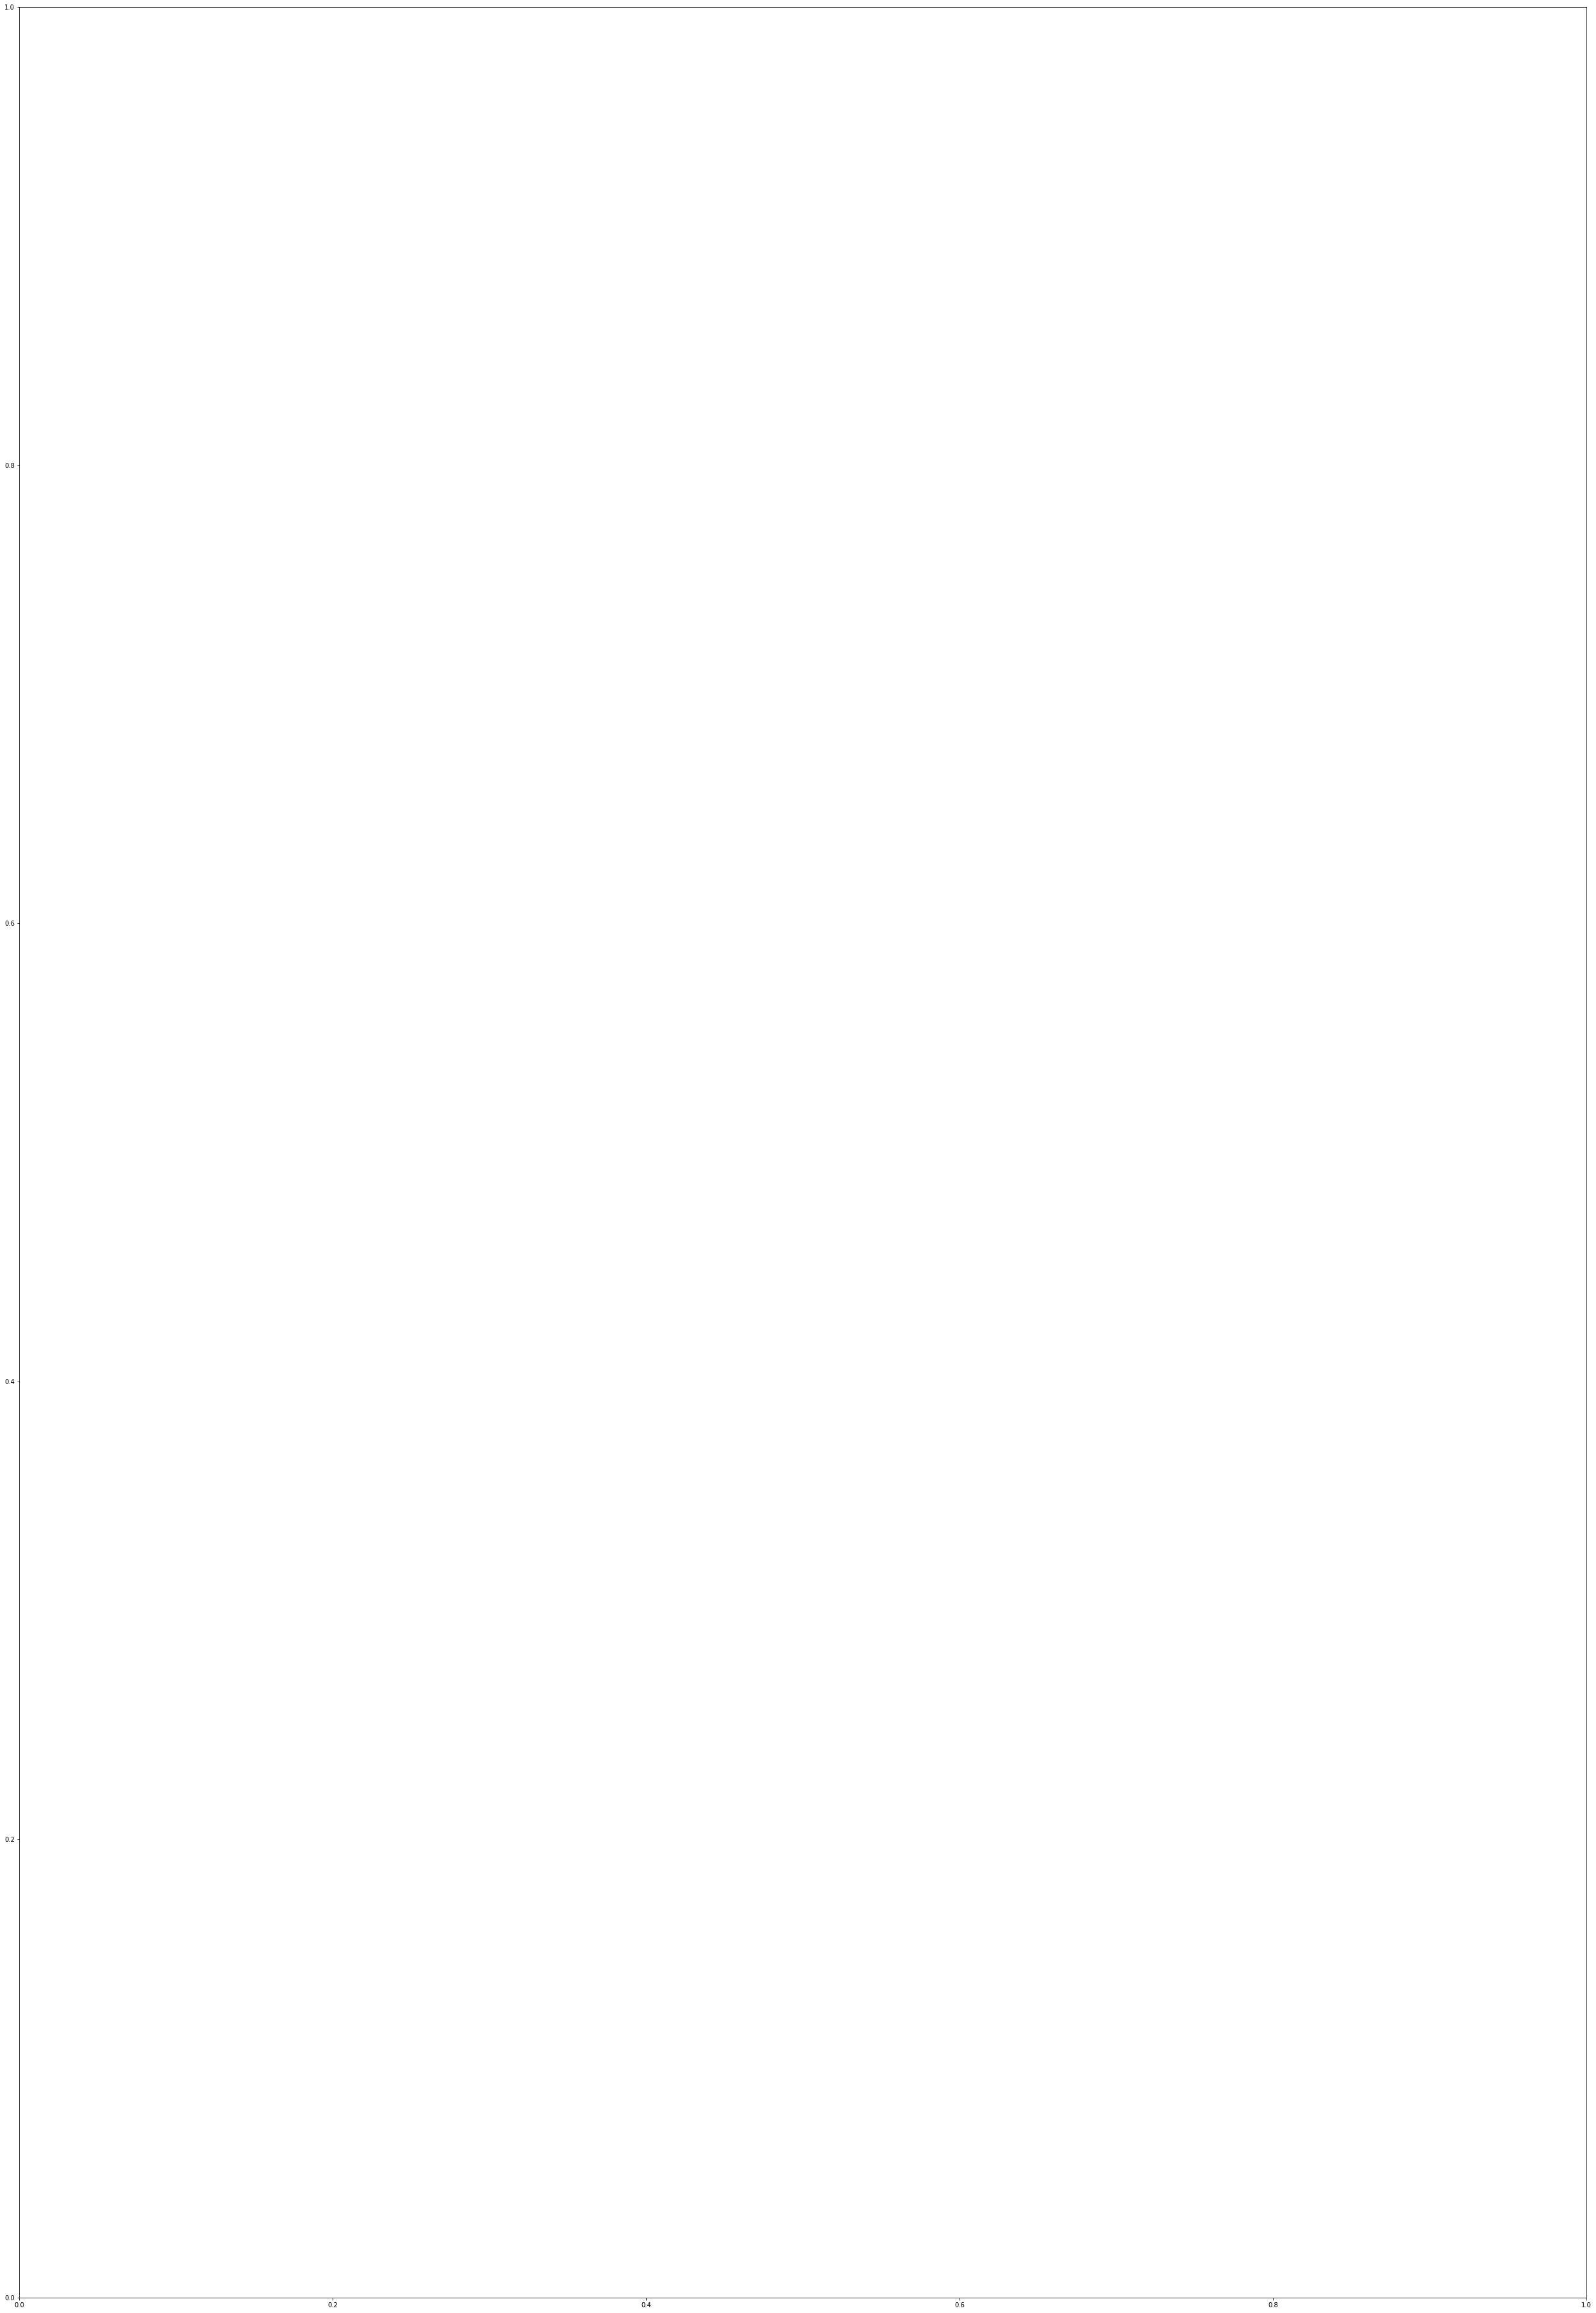

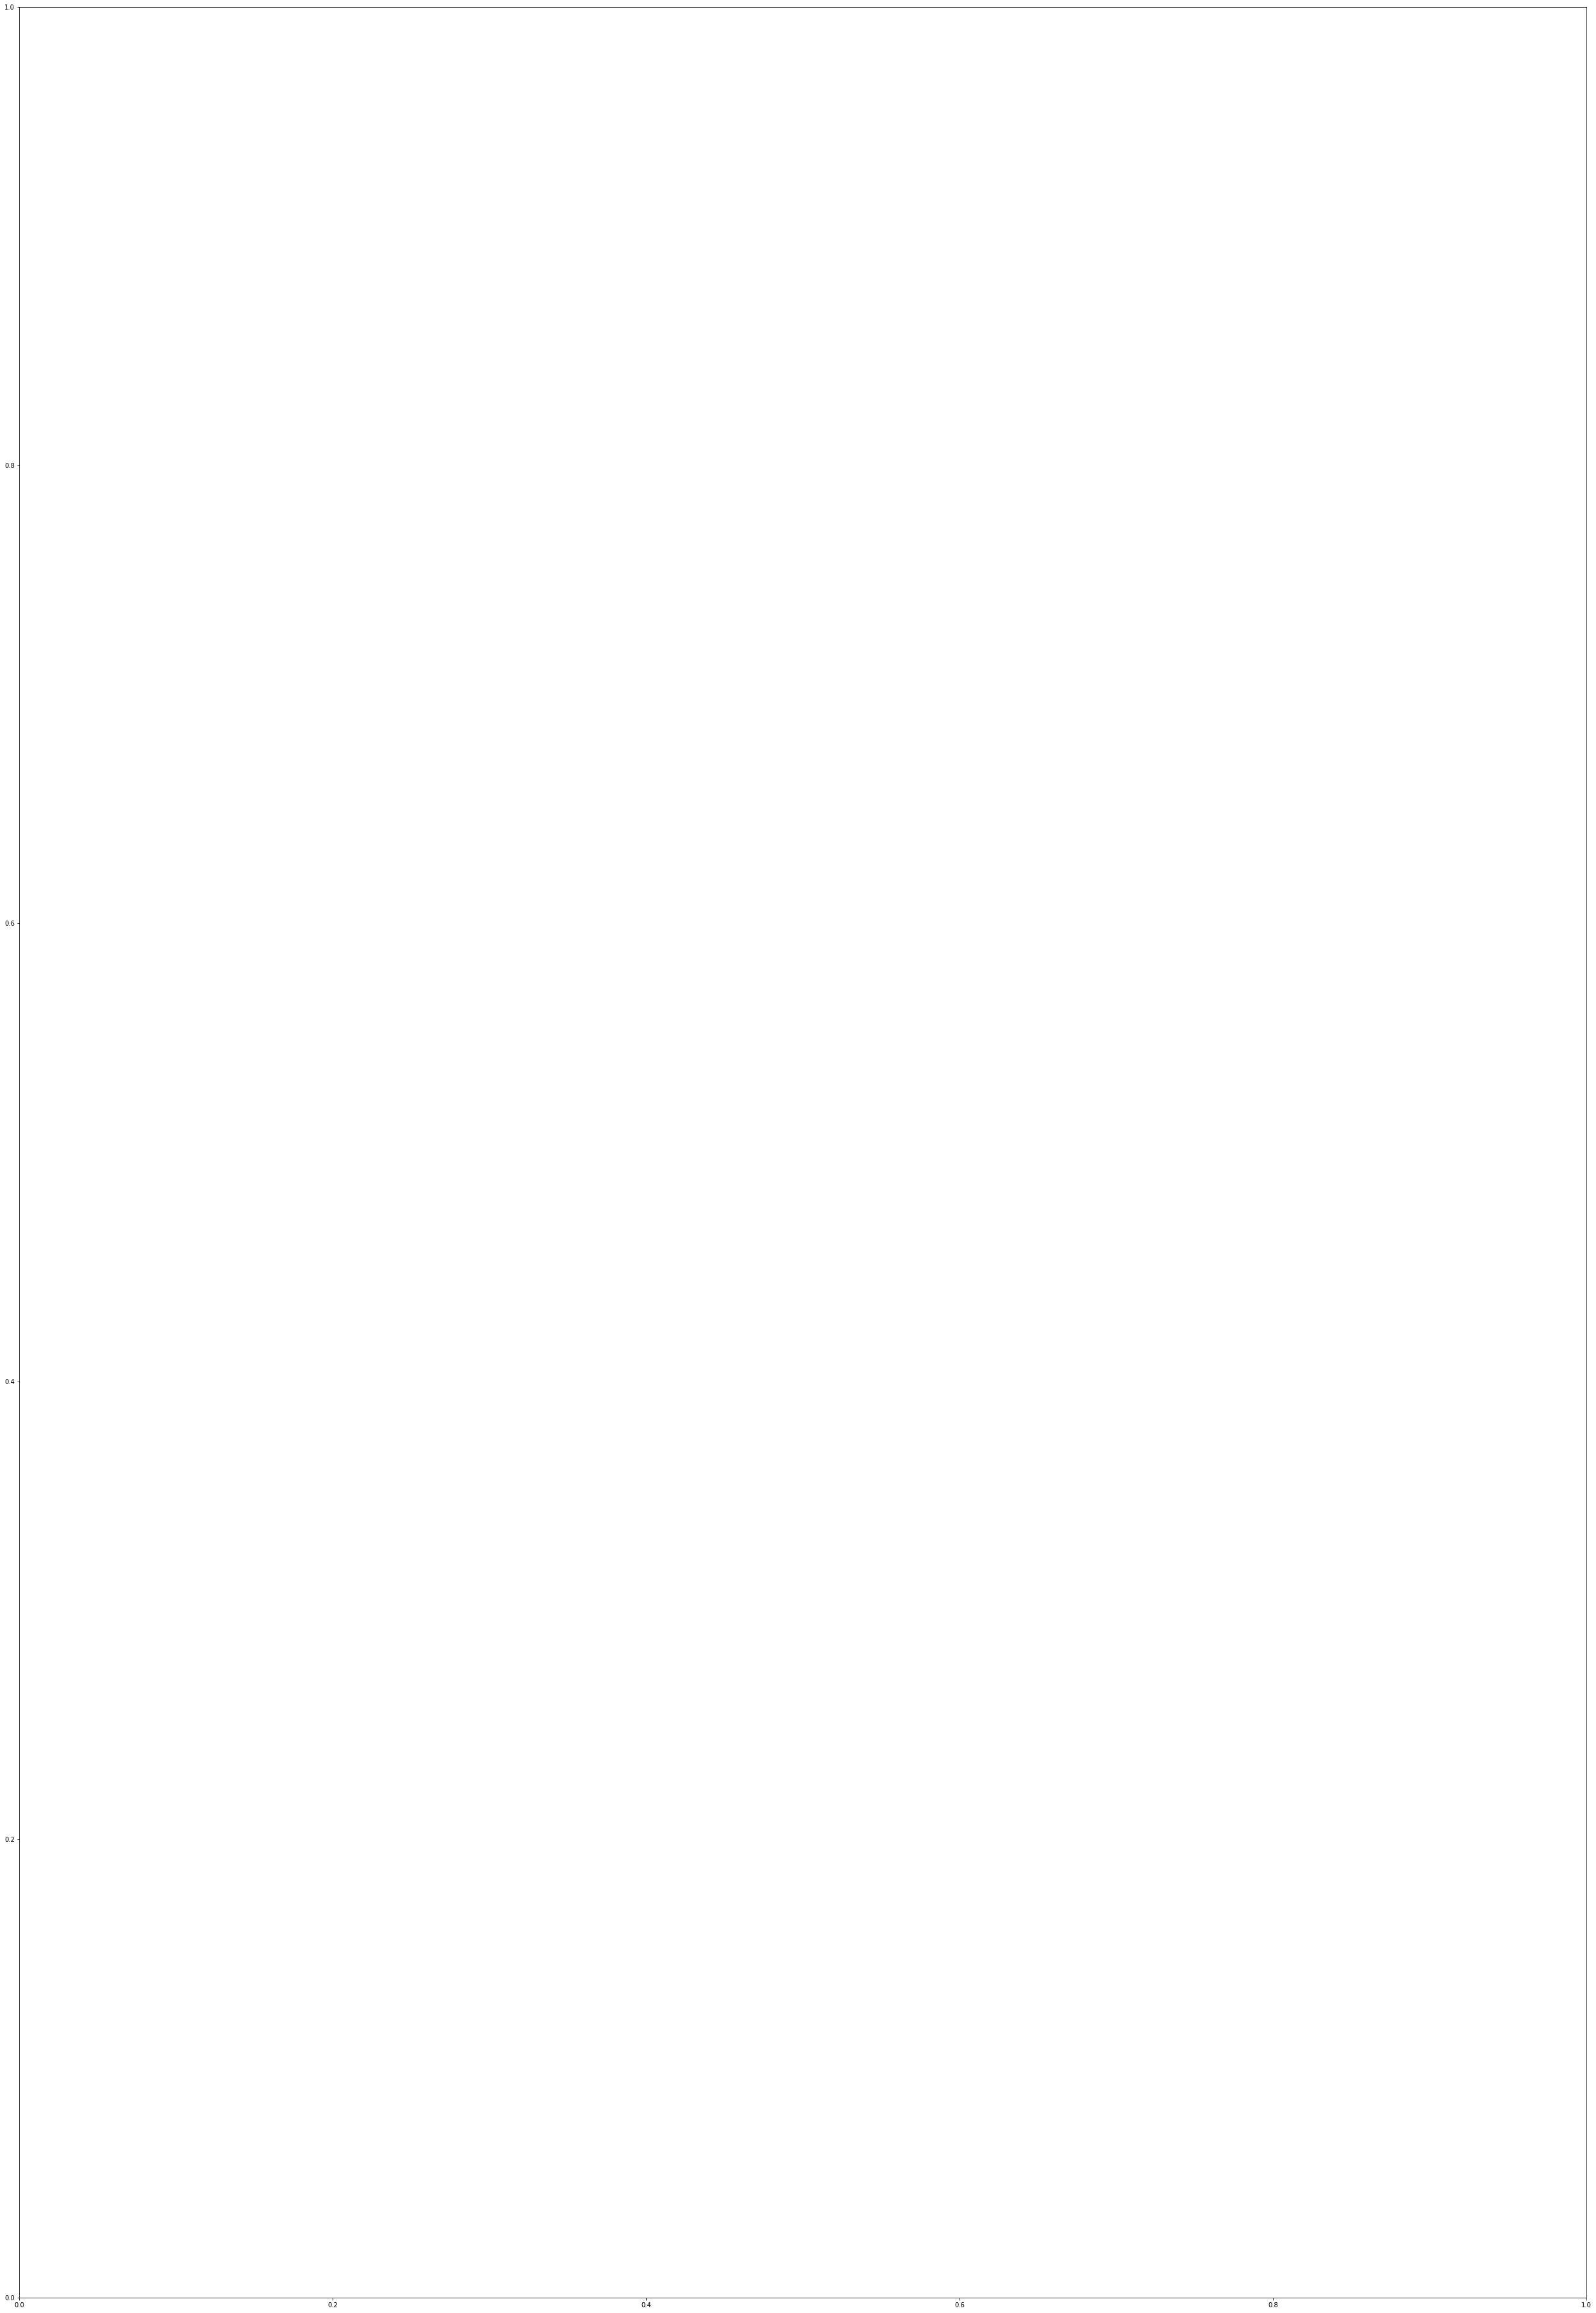

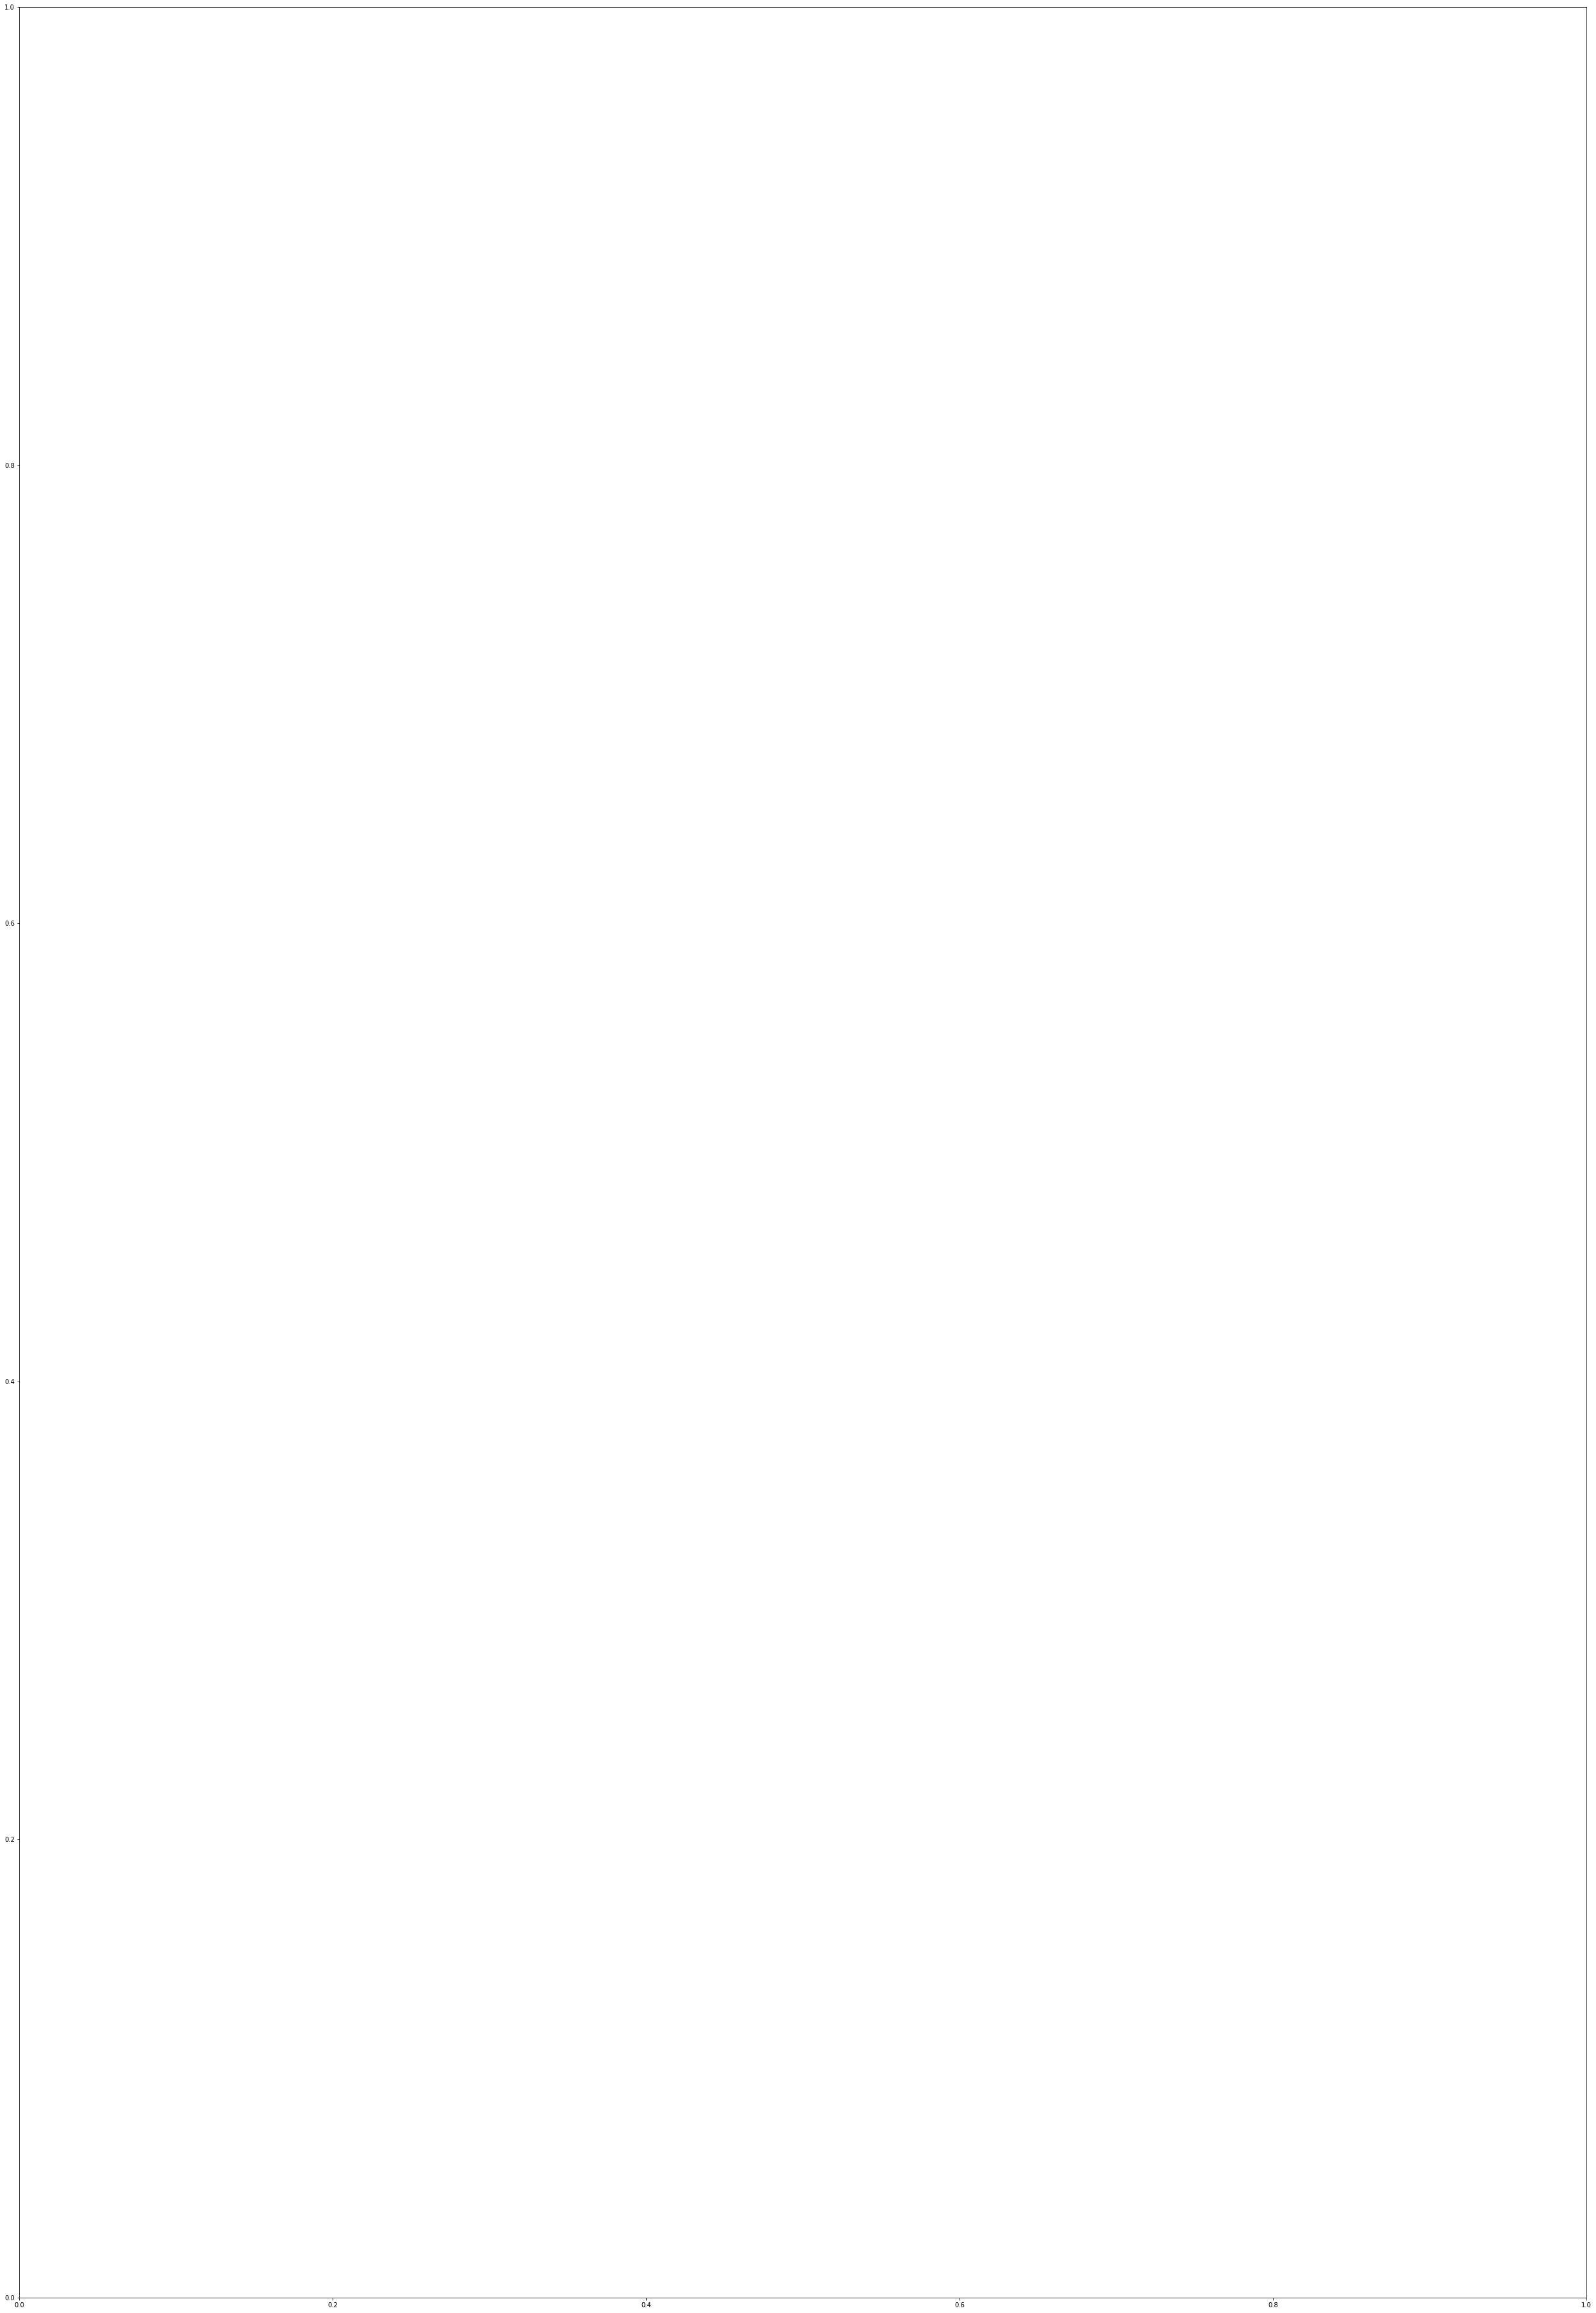

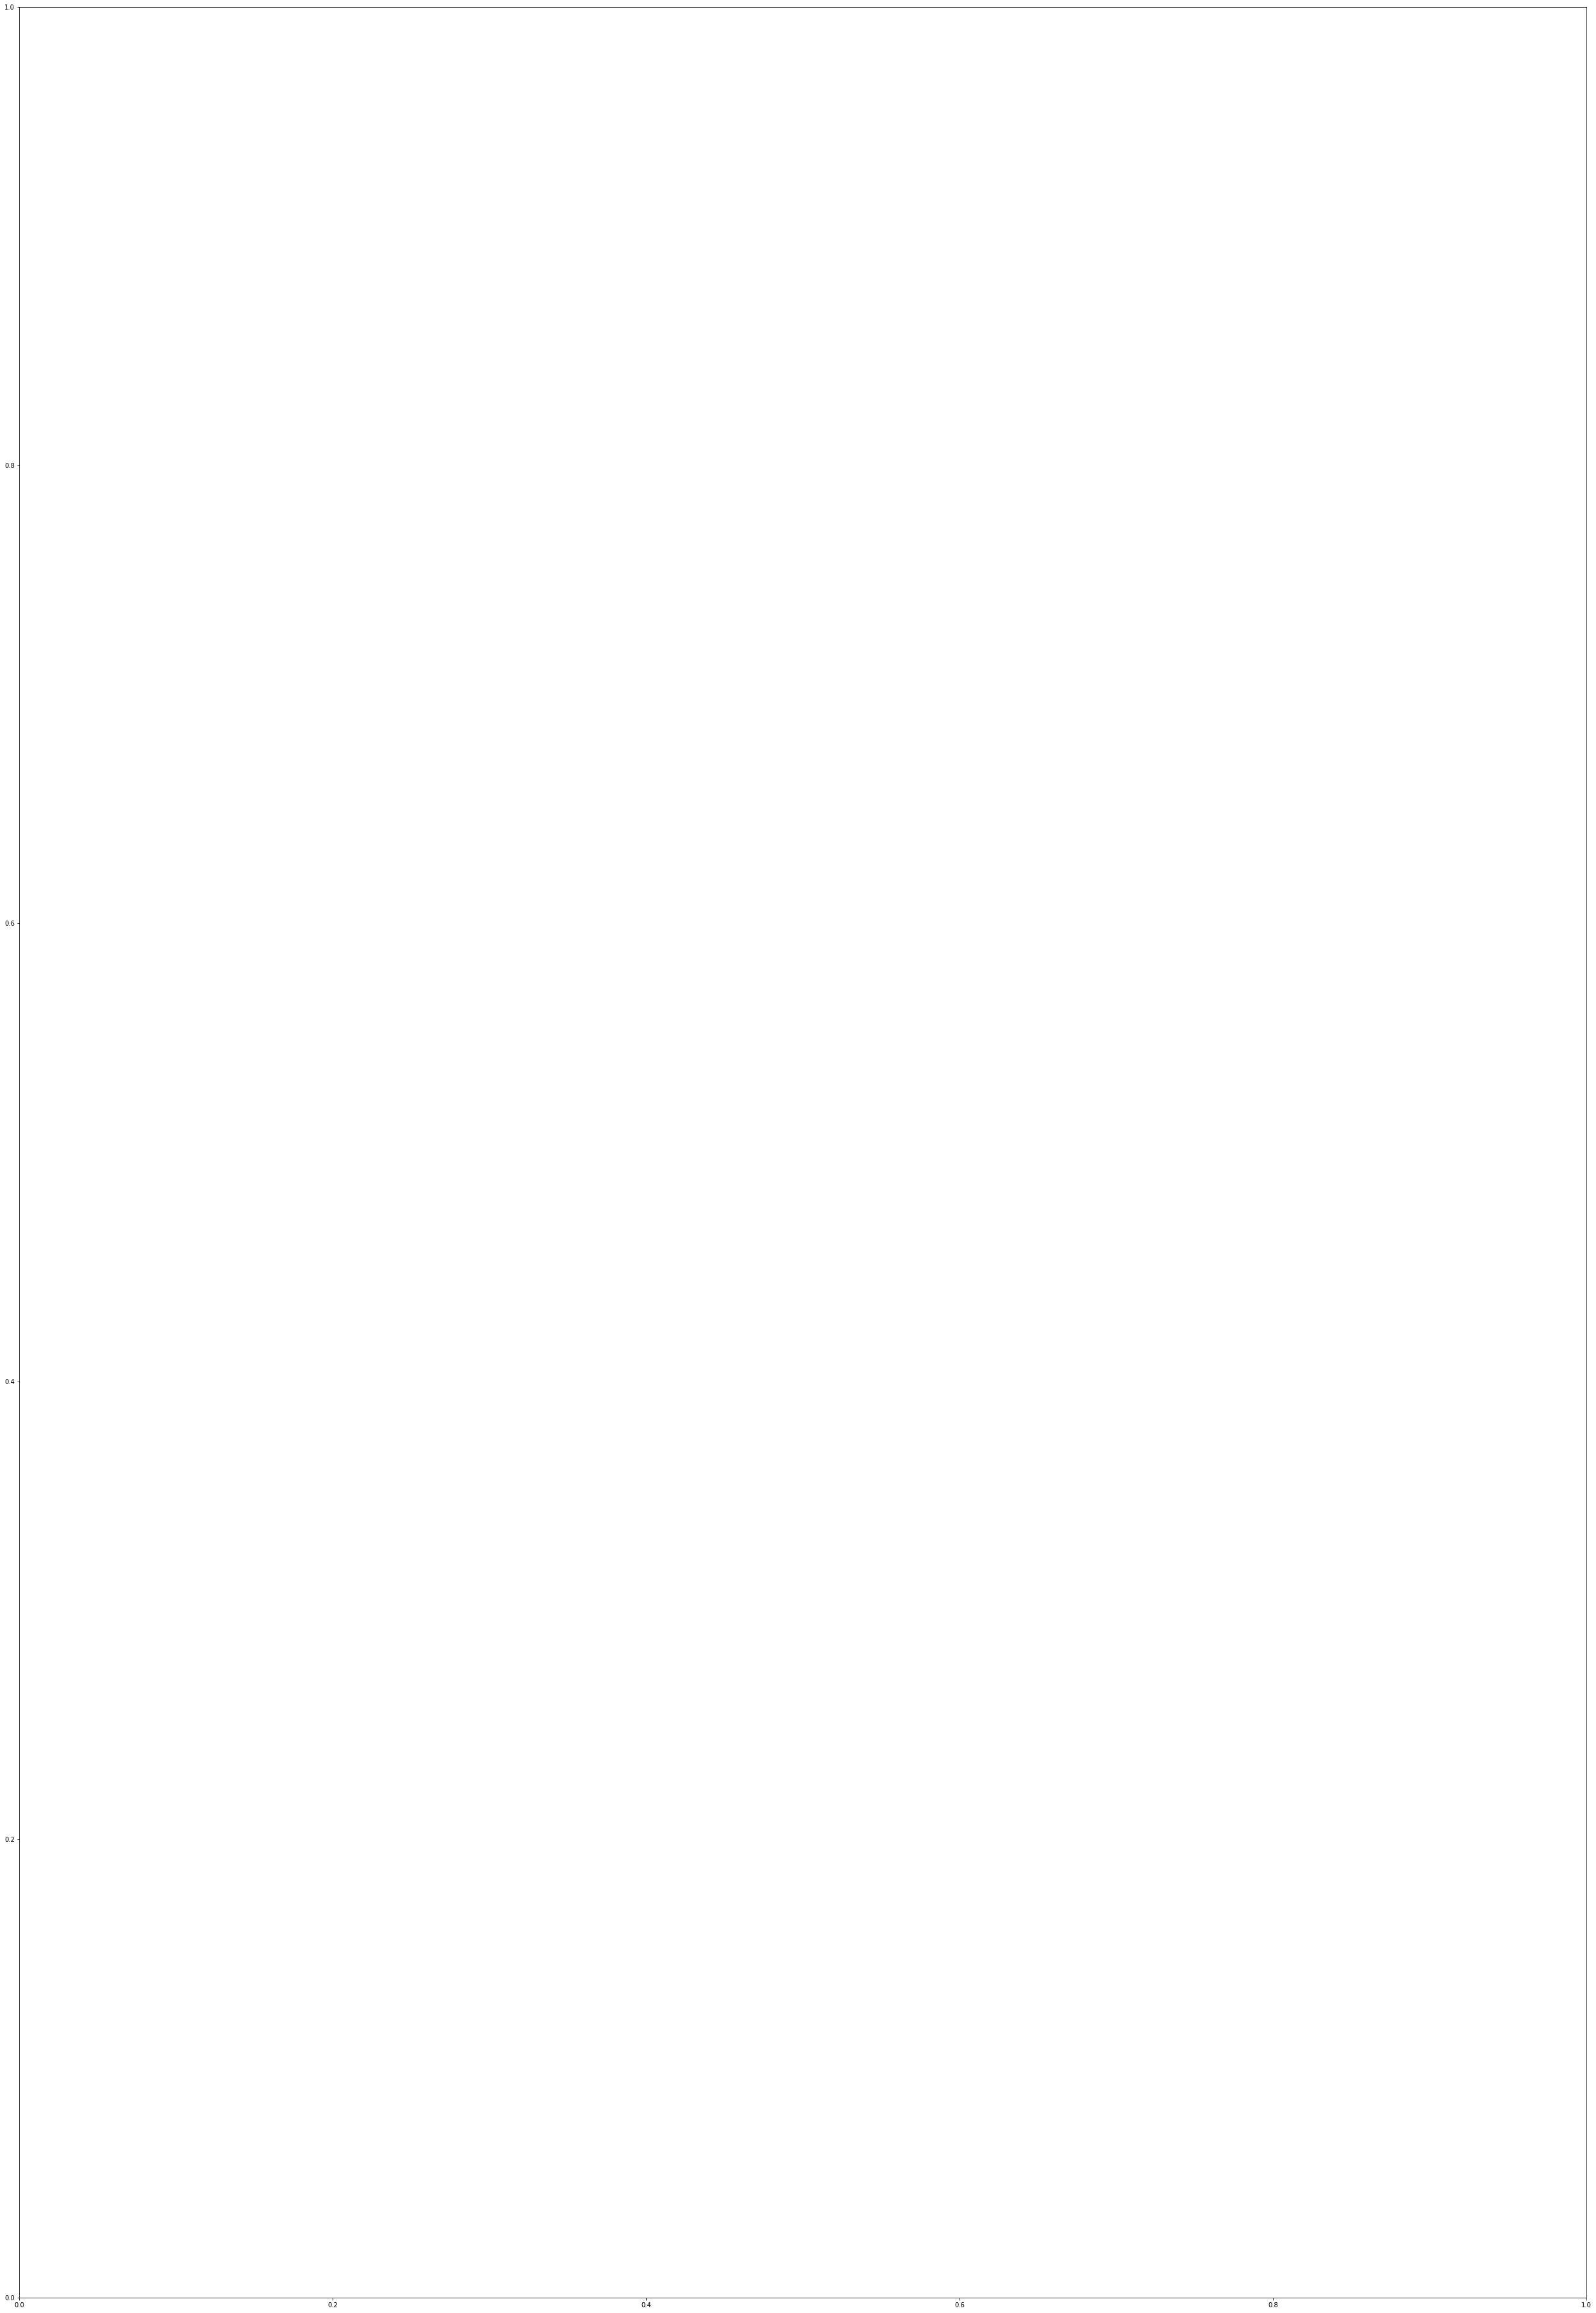

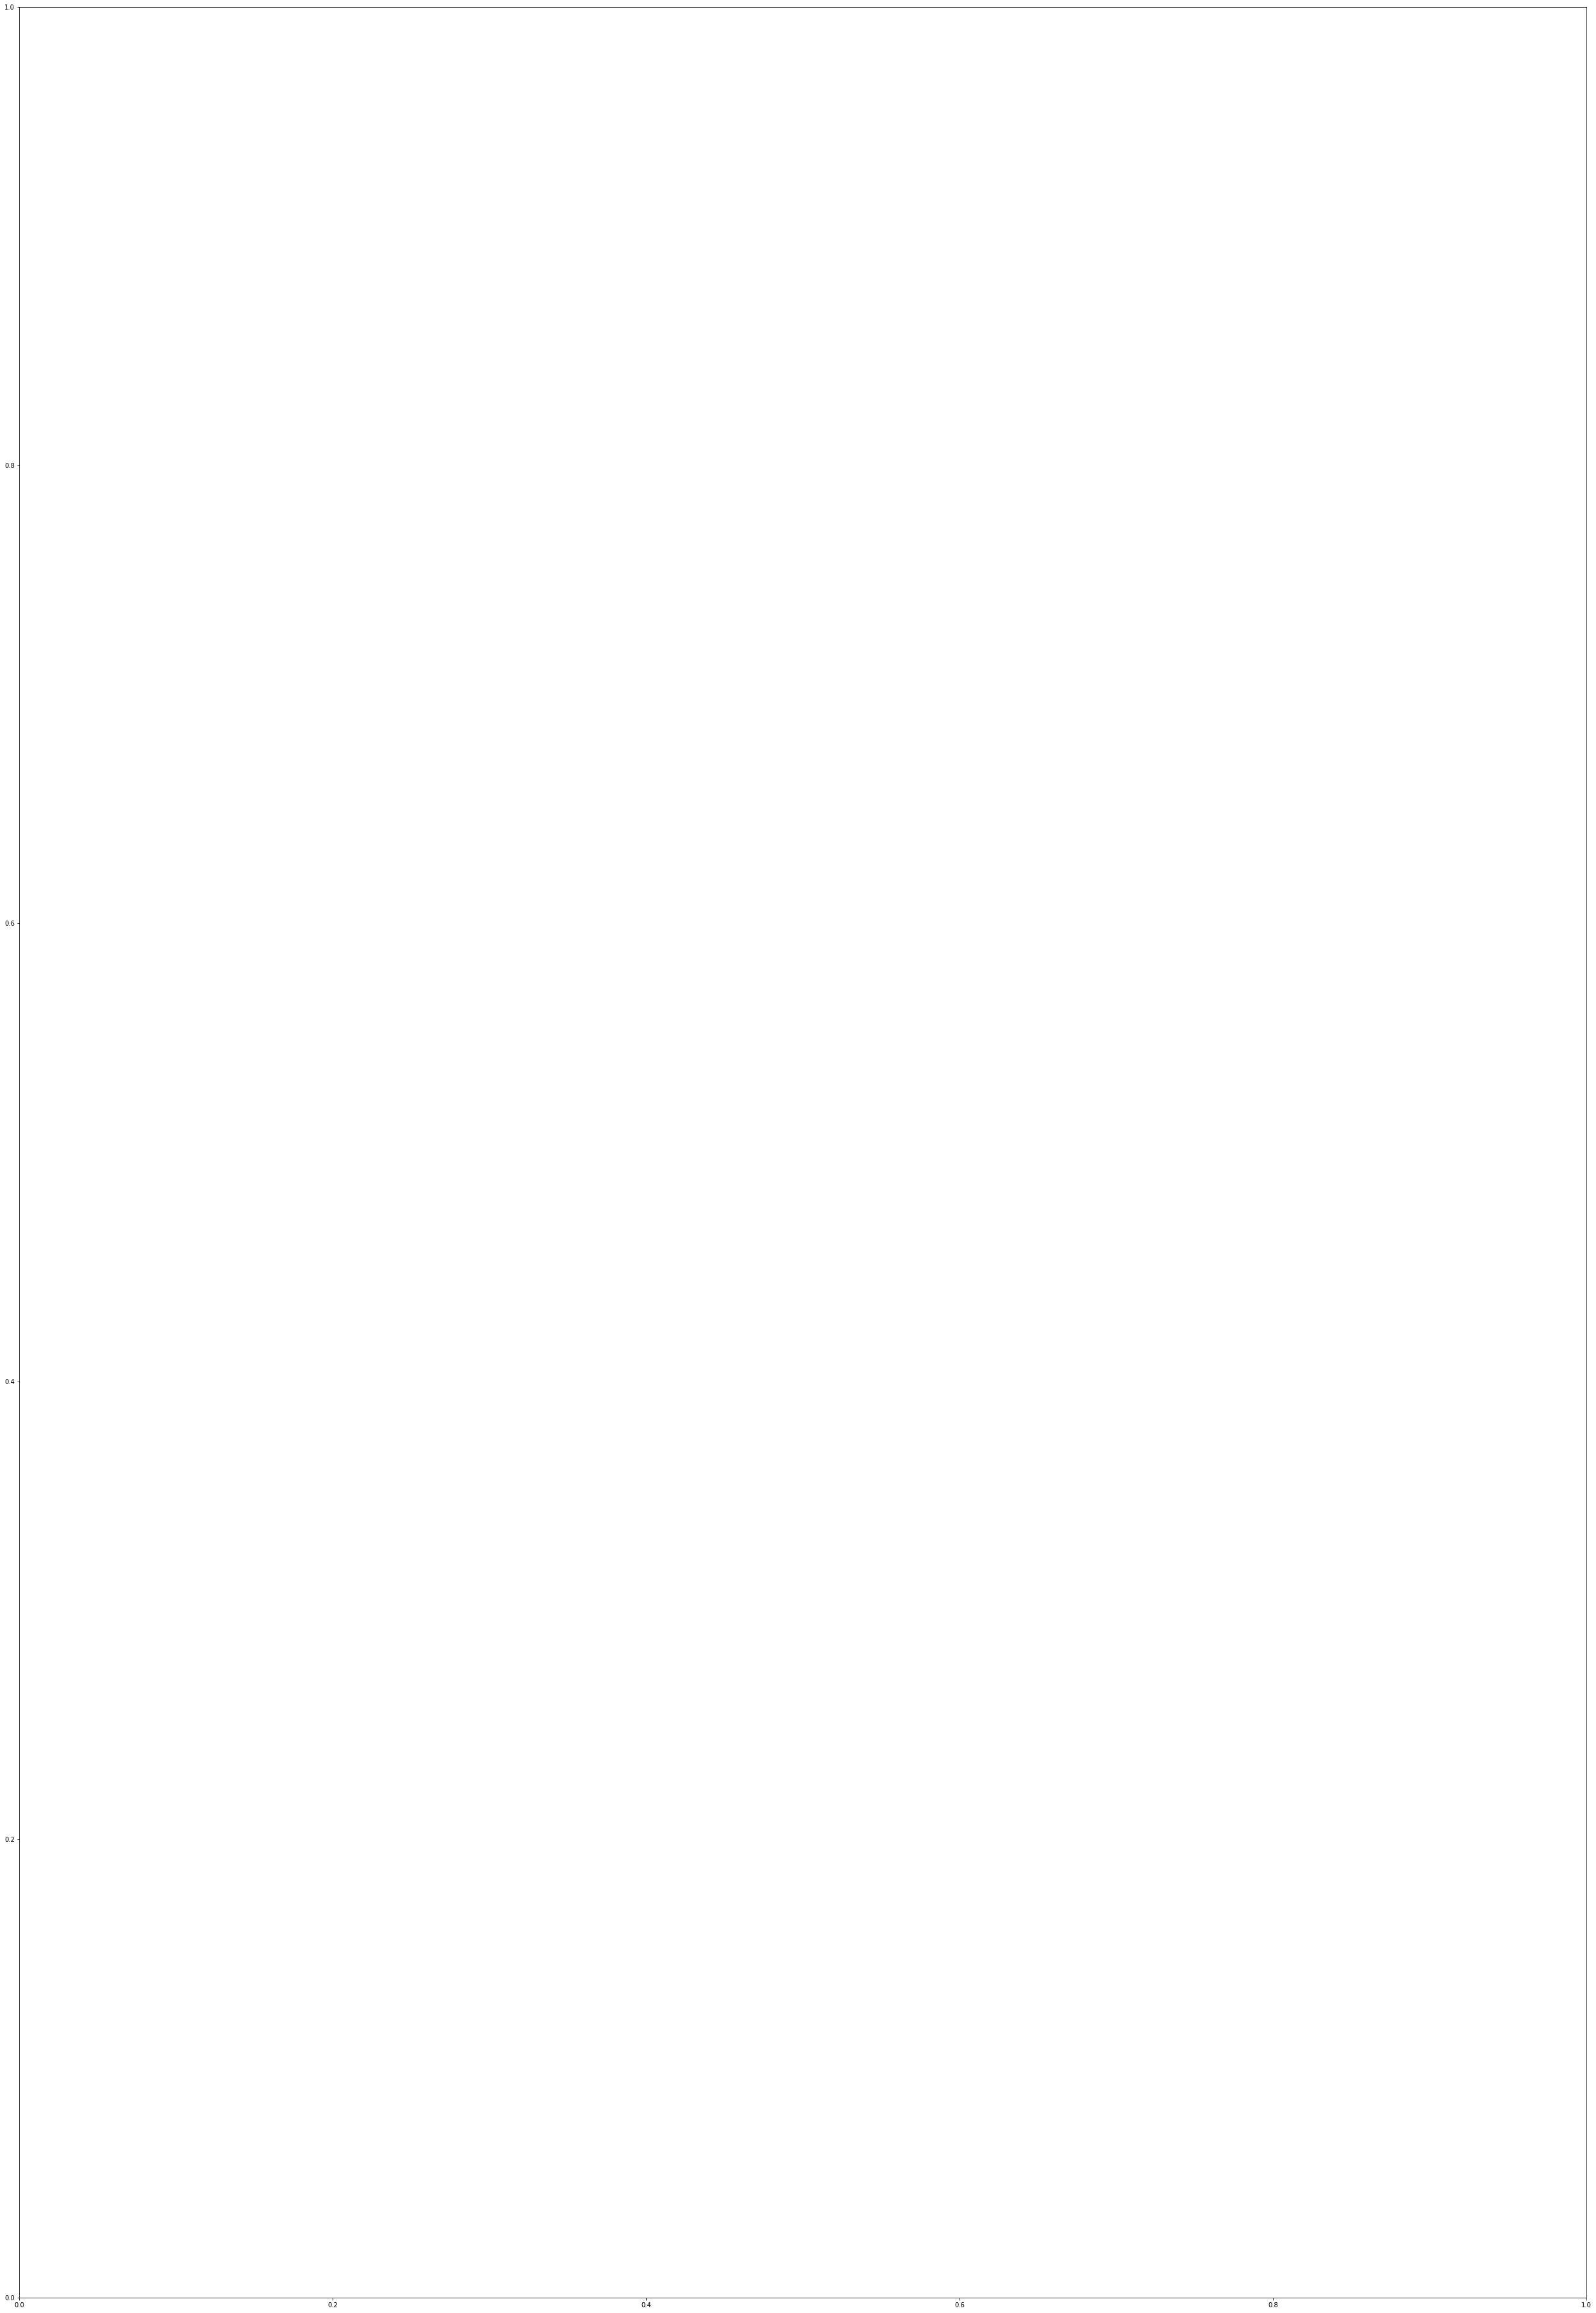

In [52]:
for i in camts2["gene_abbr"].unique():
    plot_all_gt(i)
    plt.clf()
    plt.cla()

In [ ]:
# Dec. 15, 2025
# plot ZT-peak summary profiles
